In [4]:
# @title
import os
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np
import math
import sys
import scipy
from scipy.optimize import curve_fit
from scipy.stats import linregress as lr
print(np.__version__)
print(pd.__version__)
print(scipy.__version__)
import matplotlib
print(matplotlib.__version__)

base='*/eATP-kinetics-model'

2.1.3
2.2.3
1.16.3
3.10.0
Mounted at /content/drive


In [5]:
# @title
ecto_Biwo=pd.read_csv(base+'/data/Activities/BeWo.csv',index_col=1)
ecto_RBC=pd.read_csv(base+'/data/Activities/RBC.csv',index_col=1)

masa_cel=200 #ug
print('Cell mass employed ',masa_cel,' ug')

k_h_s_e=ecto_Biwo['Sincicio'].loc['Pendiente'] # nM/(min*ug*nM ATP)
k_h_c_e=ecto_Biwo['Cito'].loc['Pendiente'] # nM/(min*ug*nM ATP)

k_h_s=k_h_s_e*200 # nM hidrolizado/(nM ATP*min)
k_h_c=k_h_c_e*200 # nM hidrolizado/(nM ATP*min)
print(ecto_RBC)
k_h_irbc=-ecto_RBC['Value'].loc['iRBC_slope']
k_h_crbc=-ecto_RBC['Value'].loc['cRBC_slope']

units=' nM hydrolized/(nM ATP*min)'

print('Condition NF54 k_hydrolisis: ',k_h_irbc+k_h_c,units)
print('Condition FCR3 k_hydrolisis: ',k_h_irbc+k_h_c,units)
print('Condition cRBCs k_hydrolisis: ',k_h_crbc+k_h_c,units)
print('Condition Mechanical stimulus k_hydrolisis: ',k_h_c,units)

Cell mass employed  200  ug
                Unnamed: 0     Value
Condition                           
iRBC_slope               0 -0.001554
iRBC_intercept           1 -0.055251
cRBC_slope               2 -0.000213
cRBC_intercept           3 -0.048202
Condition NF54 k_hydrolisis:  0.0160341503341318  nM hydrolized/(nM ATP*min)
Condition FCR3 k_hydrolisis:  0.0160341503341318  nM hydrolized/(nM ATP*min)
Condition cRBCs k_hydrolisis:  0.0146932295520491  nM hydrolized/(nM ATP*min)
Condition Mechanical stimulus k_hydrolisis:  0.01448  nM hydrolized/(nM ATP*min)


In [6]:
data_base=base+'/data/Datos.xlsx'
data_nf54=pd.read_excel(data_base,sheet_name='Data',skiprows=1,usecols="B:E",nrows=7)
data_fcr3=pd.read_excel(data_base,sheet_name='Data',skiprows=1,usecols="F:I",nrows=7)
data_rbcs=pd.read_excel(data_base,sheet_name='Data',skiprows=1,usecols="J:M",nrows=7)
data_biwo=pd.read_excel(data_base,sheet_name='Data',skiprows=1,usecols="N:O",nrows=7)
data_cm2r=pd.read_excel(data_base,sheet_name='Data',skiprows=1,usecols="R:U",nrows=7)

c_nf54=pd.read_excel(data_base,sheet_name='Data',usecols="B:E",nrows=1).columns
c_fcr3=pd.read_excel(data_base,sheet_name='Data',usecols="F:I",nrows=1).columns
c_rbcs=pd.read_excel(data_base,sheet_name='Data',usecols="J:M",nrows=1).columns
c_biwo=pd.read_excel(data_base,sheet_name='Data',usecols="N:O",nrows=1).columns
c_cm2r=pd.read_excel(data_base,sheet_name='Data',usecols="R:U",nrows=1).columns

data_nf54.columns=c_nf54
data_fcr3.columns=c_fcr3
data_rbcs.columns=c_rbcs
data_biwo.columns=c_biwo
data_cm2r.columns=c_cm2r

tiempos=[0,1,5,15,30,45]
data_nf54.index=tiempos
data_fcr3.index=tiempos
data_rbcs.index=tiempos
data_biwo.index=tiempos
data_cm2r.index=tiempos

data_m_nf54=data_nf54.mean(axis=1)
data_m_fcr3=data_fcr3.mean(axis=1)
data_m_rbcs=data_rbcs.mean(axis=1)
data_m_biwo=data_biwo.mean(axis=1)
data_m_cm2r=data_cm2r.mean(axis=1)

def preparo_data(ddff=[]):
    x=[]
    y=[]
    d={}
    for i in ddff.columns:
      for qq,j in enumerate(ddff[i]):
        x.append(ddff[i].index.values[qq])
        y.append(j)
    d['x']=x
    d['y']=y
    return pd.Series(d['y'],index=d['x'])

data_ajuste_nf54=preparo_data(data_nf54).dropna()
data_ajuste_fcr3=preparo_data(data_fcr3).dropna()
data_ajuste_rbcs=preparo_data(data_rbcs).dropna()
data_ajuste_biwo=preparo_data(data_biwo).dropna()
data_ajuste_cm2r=preparo_data(data_cm2r).dropna()

In [7]:
#Fitting of Model3

dt=0.02
#Functions
#---------------------------------------------------------

def calc_akaike(n, rss, k):
    """Calculates the Akaike Information Criterion (AIC)."""
    if (n - k - 1) <= 0:
        raise ValueError("The number of observations is too low")

    # AIC estándar
    aic = n * np.log(rss / n) + 2 * k

    # Término de corrección para muestras pequeñas/medianas
    correction = (2 * k * (k + 1)) / (n - k - 1)

    return aic + correction

def calc_rss(y_true, y_pred):
    """Calculates the Residual Sum of Squares"""
    return np.sum((np.array(y_true) - np.array(y_pred))**2)

# Model3
# ---------------------------------------------------------
def simulate_eATP_dynamics(t_eval, k_s_b, k_s_m, ATP_0, k_h, dt):
    """
    Euler integration for eATP dynamics.
    Calculates a high-resolution simulation and interpolates to match experimental times.
    """
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)

    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0

    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida = k_s_b + k_s_m * t
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt

    # Interpolate to exactly match experimental time indices (t_eval)
    return np.interp(t_eval, tiempos, ATP_sim)

#Fittinh
# ---------------------------------------------------------
def fit_experimental_condition(name, data_series, k_h, dt,n_params=3):
    """Fits Model 3 to a specific condition and returns metrics."""
    print(f"--- Fitting Condition: {name} ---")
    print(f"Total Hydrolysis Constant: {k_h:.5f}")

    # Wrapper function locks in the specific hydrolysis constants for curve_fit
    def model_wrapper(t, k_s_b, k_s_m, ATP_0):
        return simulate_eATP_dynamics(t, k_s_b, k_s_m, ATP_0, k_h,dt)

    # Perform curve fitting
    popt, pcov = curve_fit(
        model_wrapper,
        data_series.index,
        data_series.values,
        p0=[0.01, 0.01, 2],
        bounds=([0, 0, 0], [10.0, 1.0, 60.0])
    )

    k_s_b, k_s_m, ATP_0 = popt
    err_k_s_b, err_k_s_m, err_ATP_0 = np.sqrt(np.diag(pcov))

    # Calculate performance metrics
    y_pred = model_wrapper(data_series.index, k_s_b, k_s_m, ATP_0)
    rss = calc_rss(data_series.values, y_pred)
    n_points = len(data_series.index)
    aic = calc_akaike(n_points, rss, n_params)

    print(f"Basal ATP efflux: {k_s_b:.5f} ± {err_k_s_b:.5f} nM/min")
    print(f"Incremental ATP efflux: {k_s_m:.5f} ± {err_k_s_m:.5f} nM/min²")
    print(f"Initial ATP (ATP_0): {ATP_0:.3f} ± {err_ATP_0:.3f} nM")
    print(f"RSS: {rss:.2f} | AIC: {aic:.2f}\n")

    # Format output specifically for the Supplementary Table
    supp_data = [
        f"{k_s_b:.3f} ± {err_k_s_b:.3f}",
        f"({k_s_m * 1000:.2f} ± {err_k_s_m * 1000:.2f})x10-3",
        f"{ATP_0:.2f} ± {err_ATP_0:.2f}",
        str(n_points),
        f"{rss:.2f}",
        f"{aic:.2f}"
    ]

    # Raw data for internal tracking/plotting
    raw_data = [k_s_b, k_s_m, ATP_0, rss, n_points, aic]

    return supp_data, raw_data

#Fitting to each dataset
#-----
conditions = [
    {'name': 'iRBCs NF54-CSA', 'data': data_ajuste_nf54, 'k_h': k_h_irbc+k_h_c},
    {'name': 'iRBCs FCR3-CSA', 'data': data_ajuste_fcr3, 'k_h': k_h_irbc+k_h_c},
    {'name': 'cmRBCs-FCR3',         'data': data_ajuste_rbcs, 'k_h': k_h_crbc+k_h_c},
    {'name': 'Mechanical stimulus', 'data': data_ajuste_biwo, 'k_h': +k_h_c},
    {'name': 'cmRBCs-NF54', 'data': data_ajuste_cm2r, 'k_h': +k_h_crbc+k_h_c}
]

# Initialize output dictionaries
ajustes_dict = {
    'Parameters': ['K salida basal', 'K salida ATP en función del tiempo', 'ATP0', 'Suma residuales', 'N', 'Akaike']
}
supplementary_dict = {
    'Data': ['Parameter kefflux-constant', 'Parameter kefflux-variable', 'Initial [eATP]', 'Data points', 'Residuals sum', 'Akaike information criterion']
}

# Run the fits iteratively
for cond in conditions:
    supp_res, raw_res = fit_experimental_condition(
        name=cond['name'],
        data_series=cond['data'],
        k_h=cond['k_h'],
        dt=dt
    )
    supplementary_dict[cond['name']] = supp_res
    ajustes_dict[cond['name']] = raw_res

ajustes_dict['Unidades'] = ['nM salida/min', 'nM salida/(min**2)', 'nM', '', '', '']

# ---------------------------------------------------------
# 5. Export Results (Using Local Relative Paths for GitHub)
# ---------------------------------------------------------
output_dir = base+'/Results'
os.makedirs(output_dir, exist_ok=True)

pd.DataFrame(ajustes_dict).to_csv(f'{output_dir}/Ajustes_Modelo_3_offline.csv', index=False)
pd.DataFrame(supplementary_dict).to_csv(f'{output_dir}/Supplementary_modelo3.csv', sep=';', decimal=',', index=False)

print("Fitting complete. Data saved to local directory.")

--- Fitting Condition: iRBCs NF54-CSA ---
Total Hydrolysis Constant: 0.01603
Basal ATP efflux: 0.01687 ± 0.00988 nM/min
Incremental ATP efflux: 0.00040 ± 0.00046 nM/min²
Initial ATP (ATP_0): 0.215 ± 0.063 nM
RSS: 0.67 | AIC: -69.51

--- Fitting Condition: iRBCs FCR3-CSA ---
Total Hydrolysis Constant: 0.01603
Basal ATP efflux: 0.01686 ± 0.02474 nM/min
Incremental ATP efflux: 0.00172 ± 0.00107 nM/min²
Initial ATP (ATP_0): 0.304 ± 0.166 nM
RSS: 5.12 | AIC: -29.86

--- Fitting Condition: cmRBCs-FCR3 ---
Total Hydrolysis Constant: 0.01469
Basal ATP efflux: 0.00000 ± 0.01485 nM/min
Incremental ATP efflux: 0.00103 ± 0.00064 nM/min²
Initial ATP (ATP_0): 0.262 ± 0.100 nM
RSS: 1.87 | AIC: -54.11

--- Fitting Condition: Mechanical stimulus ---
Total Hydrolysis Constant: 0.01448
Basal ATP efflux: 0.00600 ± 0.00439 nM/min
Incremental ATP efflux: 0.00014 ± 0.00019 nM/min²
Initial ATP (ATP_0): 0.320 ± 0.030 nM
RSS: 0.03 | AIC: -61.06

--- Fitting Condition: cmRBCs-NF54 ---
Total Hydrolysis Constant: 

In [8]:
#Fitting of Model2


def simulate_eATP_dynamics(t_eval, k_s_m, ATP_0, k_h, dt):
    """
    Euler integration for eATP dynamics.
    Calculates a high-resolution simulation and interpolates to match experimental times.
    """
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)

    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0

    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida =  k_s_m * t
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt

    # Interpolate to exactly match experimental time indices (t_eval)
    return np.interp(t_eval, tiempos, ATP_sim)

#Fittinh
# ---------------------------------------------------------
def fit_experimental_condition(name, data_series, k_h, dt,n_params=2):
    """Fits Model 3 to a specific condition and returns metrics."""
    print(f"--- Fitting Condition: {name} ---")
    print(f"Total Hydrolysis Constant: {k_h:.5f}")

    # Wrapper function locks in the specific hydrolysis constants for curve_fit
    def model_wrapper(t, k_s_m, ATP_0):
        return simulate_eATP_dynamics(t, k_s_m, ATP_0, k_h,dt)

    # Perform curve fitting
    popt, pcov = curve_fit(
        model_wrapper,
        data_series.index,
        data_series.values,
        p0=[ 0.01, 2],
        bounds=([0, 0], [1.0, 60.0])
    )

    k_s_m, ATP_0 = popt
    err_k_s_m, err_ATP_0 = np.sqrt(np.diag(pcov))

    # Calculate performance metrics
    y_pred = model_wrapper(data_series.index, k_s_m, ATP_0)
    rss = calc_rss(data_series.values, y_pred)
    n_points = len(data_series.index)
    aic = calc_akaike(n_points, rss, n_params)

    print(f"Incremental ATP efflux: {k_s_m:.5f} ± {err_k_s_m:.5f} nM/min²")
    print(f"Initial ATP (ATP_0): {ATP_0:.3f} ± {err_ATP_0:.3f} nM")
    print(f"RSS: {rss:.2f} | AIC: {aic:.2f}\n")

    # Format output specifically for the Supplementary Table
    supp_data = [
        f"({k_s_m * 1000:.2f} ± {err_k_s_m * 1000:.2f})x10-3",
        f"{ATP_0:.2f} ± {err_ATP_0:.2f}",
        str(n_points),
        f"{rss:.2f}",
        f"{aic:.2f}"
    ]

    # Raw data for internal tracking/plotting
    raw_data = [k_s_m, ATP_0, rss, n_points, aic]

    return supp_data, raw_data

#Fitting to each dataset
#-----
conditions = [
    {'name': 'iRBCs NF54-CSA', 'data': data_ajuste_nf54, 'k_h': k_h_irbc+k_h_c},
    {'name': 'iRBCs FCR3-CSA', 'data': data_ajuste_fcr3, 'k_h': k_h_irbc+k_h_c},
    {'name': 'cmRBCs-FCR3',         'data': data_ajuste_rbcs, 'k_h': k_h_crbc+k_h_c},
    {'name': 'Mechanical stimulus', 'data': data_ajuste_biwo, 'k_h': +k_h_c},
    {'name': 'cmRBCs-NF54',         'data': data_ajuste_cm2r, 'k_h': k_h_crbc+k_h_c}
]

# Initialize output dictionaries
ajustes_dict = {
    'Parameters': ['K salida ATP en función del tiempo', 'ATP0', 'Suma residuales', 'N', 'Akaike']
}
supplementary_dict = {
    'Data': ['Parameter kefflux-variable', 'Initial [eATP]', 'Data points', 'Residuals sum', 'Akaike information criterion']
}

# Run the fits iteratively
for cond in conditions:
    supp_res, raw_res = fit_experimental_condition(
        name=cond['name'],
        data_series=cond['data'],
        k_h=cond['k_h'],
        dt=dt
    )
    supplementary_dict[cond['name']] = supp_res
    ajustes_dict[cond['name']] = raw_res

ajustes_dict['Unidades'] = ['nM salida/(min**2)', 'nM', '', '', '']

# ---------------------------------------------------------
# 5. Export Results (Using Local Relative Paths for GitHub)
# ---------------------------------------------------------
output_dir = base+'/Results'
os.makedirs(output_dir, exist_ok=True)

pd.DataFrame(ajustes_dict).to_csv(f'{output_dir}/Ajustes_Modelo_2_offline.csv', index=False)
pd.DataFrame(supplementary_dict).to_csv(f'{output_dir}/Supplementary_modelo2.csv', sep=';', decimal=',', index=False)

print("Fitting complete. Data saved to local directory.")

--- Fitting Condition: iRBCs NF54-CSA ---
Total Hydrolysis Constant: 0.01603
Incremental ATP efflux: 0.00115 ± 0.00015 nM/min²
Initial ATP (ATP_0): 0.279 ± 0.054 nM
RSS: 0.77 | AIC: -69.06

--- Fitting Condition: iRBCs FCR3-CSA ---
Total Hydrolysis Constant: 0.01603
Incremental ATP efflux: 0.00242 ± 0.00030 nM/min²
Initial ATP (ATP_0): 0.372 ± 0.132 nM
RSS: 5.24 | AIC: -31.97

--- Fitting Condition: cmRBCs-FCR3 ---
Total Hydrolysis Constant: 0.01469
Incremental ATP efflux: 0.00103 ± 0.00017 nM/min²
Initial ATP (ATP_0): 0.262 ± 0.078 nM
RSS: 1.87 | AIC: -56.74

--- Fitting Condition: Mechanical stimulus ---
Total Hydrolysis Constant: 0.01448
Incremental ATP efflux: 0.00039 ± 0.00006 nM/min²
Initial ATP (ATP_0): 0.344 ± 0.025 nM
RSS: 0.04 | AIC: -62.46

--- Fitting Condition: cmRBCs-NF54 ---
Total Hydrolysis Constant: 0.01469
Incremental ATP efflux: 0.00064 ± 0.00008 nM/min²
Initial ATP (ATP_0): 0.288 ± 0.027 nM
RSS: 0.20 | AIC: -99.27

Fitting complete. Data saved to local directory.


In [9]:
#Fitting of Model1


def simulate_eATP_dynamics(t_eval, k_s_b, ATP_0, k_h, dt):
    """
    Euler integration for eATP dynamics.
    Calculates a high-resolution simulation and interpolates to match experimental times.
    """
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)

    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0

    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida =  k_s_b
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt

    # Interpolate to exactly match experimental time indices (t_eval)
    return np.interp(t_eval, tiempos, ATP_sim)

#Fittinh
# ---------------------------------------------------------
def fit_experimental_condition(name, data_series, k_h, dt,n_params=2):
    """Fits Model 3 to a specific condition and returns metrics."""
    print(f"--- Fitting Condition: {name} ---")
    print(f"Total Hydrolysis Constant: {k_h:.5f}")

    # Wrapper function locks in the specific hydrolysis constants for curve_fit
    def model_wrapper(t, k_s_b, ATP_0):
        return simulate_eATP_dynamics(t, k_s_b, ATP_0, k_h,dt)

    # Perform curve fitting
    popt, pcov = curve_fit(
        model_wrapper,
        data_series.index,
        data_series.values,
        p0=[ 0.01, 2],
        bounds=([0, 0], [10.0, 60.0])
    )

    k_s_b, ATP_0 = popt
    err_k_s_b, err_ATP_0 = np.sqrt(np.diag(pcov))

    # Calculate performance metrics
    y_pred = model_wrapper(data_series.index, k_s_b, ATP_0)
    rss = calc_rss(data_series.values, y_pred)
    n_points = len(data_series.index)
    aic = calc_akaike(n_points, rss, n_params)

    print(f"Fixed ATP efflux: {k_s_b:.5f} ± {err_k_s_b:.5f} nM/min")
    print(f"Initial ATP (ATP_0): {ATP_0:.3f} ± {err_ATP_0:.3f} nM")
    print(f"RSS: {rss:.2f} | AIC: {aic:.2f}\n")

    # Format output specifically for the Supplementary Table
    supp_data = [
        f"({k_s_b:.4f} ± {err_k_s_b:.4f})",
        f"{ATP_0:.2f} ± {err_ATP_0:.2f}",
        str(n_points),
        f"{rss:.2f}",
        f"{aic:.2f}"
    ]

    # Raw data for internal tracking/plotting
    raw_data = [k_s_b, ATP_0, rss, n_points, aic]

    return supp_data, raw_data

#Fitting to each dataset
#-----
conditions = [
    {'name': 'iRBCs NF54-CSA', 'data': data_ajuste_nf54, 'k_h': k_h_irbc+k_h_c},
    {'name': 'iRBCs FCR3-CSA', 'data': data_ajuste_fcr3, 'k_h': k_h_irbc+k_h_c},
    {'name': 'cmRBCs-FCR3',         'data': data_ajuste_rbcs, 'k_h': k_h_crbc+k_h_c},
    {'name': 'Mechanical stimulus', 'data': data_ajuste_biwo, 'k_h': +k_h_c},
    {'name': 'cmRBCs-NF54',         'data': data_ajuste_cm2r, 'k_h': k_h_crbc+k_h_c},
]

# Initialize output dictionaries
ajustes_dict = {
    'Parameters': ['ATP en función del tiempo', 'ATP0', 'Suma residuales', 'N', 'Akaike']
}
supplementary_dict = {
    'Data': ['Parameter kefflux', 'Initial [eATP]', 'Data points', 'Residuals sum', 'Akaike information criterion']
}

# Run the fits iteratively
for cond in conditions:
    supp_res, raw_res = fit_experimental_condition(
        name=cond['name'],
        data_series=cond['data'],
        k_h=cond['k_h'],
        dt=dt
    )
    supplementary_dict[cond['name']] = supp_res
    ajustes_dict[cond['name']] = raw_res

ajustes_dict['Unidades'] = ['nM salida/min', 'nM', '', '', '']

# ---------------------------------------------------------
# 5. Export Results (Using Local Relative Paths for GitHub)
# ---------------------------------------------------------
output_dir = base+'/Results'
os.makedirs(output_dir, exist_ok=True)

pd.DataFrame(ajustes_dict).to_csv(f'{output_dir}/Ajustes_Modelo_1_offline.csv', index=False)
pd.DataFrame(supplementary_dict).to_csv(f'{output_dir}/Supplementary_modelo1.csv', sep=';', decimal=',', index=False)

print("Fitting complete. Data saved to local directory.")

--- Fitting Condition: iRBCs NF54-CSA ---
Total Hydrolysis Constant: 0.01603
Fixed ATP efflux: 0.02505 ± 0.00309 nM/min
Initial ATP (ATP_0): 0.190 ± 0.056 nM
RSS: 0.70 | AIC: -71.34

--- Fitting Condition: iRBCs FCR3-CSA ---
Total Hydrolysis Constant: 0.01603
Fixed ATP efflux: 0.05516 ± 0.00718 nM/min
Initial ATP (ATP_0): 0.176 ± 0.151 nM
RSS: 5.76 | AIC: -29.69

--- Fitting Condition: cmRBCs-FCR3 ---
Total Hydrolysis Constant: 0.01469
Fixed ATP efflux: 0.02256 ± 0.00434 nM/min
Initial ATP (ATP_0): 0.188 ± 0.092 nM
RSS: 2.16 | AIC: -53.18

--- Fitting Condition: Mechanical stimulus ---
Total Hydrolysis Constant: 0.01448
Fixed ATP efflux: 0.00920 ± 0.00119 nM/min
Initial ATP (ATP_0): 0.309 ± 0.025 nM
RSS: 0.04 | AIC: -63.98

--- Fitting Condition: cmRBCs-NF54 ---
Total Hydrolysis Constant: 0.01469
Fixed ATP efflux: 0.01392 ± 0.00152 nM/min
Initial ATP (ATP_0): 0.237 ± 0.028 nM
RSS: 0.17 | AIC: -102.04

Fitting complete. Data saved to local directory.


In [10]:
#Fitting of Model4

dt=0.02
#Functions
#---------------------------------------------------------
def calc_rss(y_true, y_pred):
    """Calculates the Residual Sum of Squares (Suma Rústica)."""
    return np.sum((np.array(y_true) - np.array(y_pred))**2)

# Model3
# ---------------------------------------------------------
def simulate_eATP_dynamics(t_eval, k_s_A, k_s_exp, ATP_0, k_h, dt):
    """
    Euler integration for eATP dynamics.
    Calculates a high-resolution simulation and interpolates to match experimental times.
    """
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)

    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0

    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida = k_s_A*(1-np.exp(-k_s_exp * t))
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt

    # Interpolate to exactly match experimental time indices (t_eval)
    return np.interp(t_eval, tiempos, ATP_sim)

#Fittinh
# ---------------------------------------------------------
def fit_experimental_condition(name, data_series, k_h, dt,n_params=3):
    """Fits Model 3 to a specific condition and returns metrics."""
    print(f"--- Fitting Condition: {name} ---")
    print(f"Total Hydrolysis Constant: {k_h:.5f}")

    # Wrapper function locks in the specific hydrolysis constants for curve_fit
    def model_wrapper(t, k_s_A, k_s_exp, ATP_0):
        return simulate_eATP_dynamics(t, k_s_A, k_s_exp, ATP_0, k_h,dt)

    # Perform curve fitting
    popt, pcov = curve_fit(
        model_wrapper,
        data_series.index,
        data_series.values,
        p0=[0.2, 0.001, 0.2],
        bounds=([0.00001, 0.00001, 0], [10, 0.5, 1.0])
    )

    k_s_A, k_s_exp, ATP_0 = popt
    err_k_s_A, err_k_s_exp, err_ATP_0 = np.sqrt(np.diag(pcov))

    # Calculate performance metrics
    y_pred = model_wrapper(data_series.index, k_s_A, k_s_exp, ATP_0)
    rss = calc_rss(data_series.values, y_pred)
    n_points = len(data_series.index)
    aic = calc_akaike(n_points, rss, n_params)

    print(f"Maximal ATP efflux: {k_s_A:.5f} ± {err_k_s_exp:.5f} nM/min")
    print("ATP efflux growth kinetics: "+ str(k_s_exp)+" ± "+str(err_k_s_exp))
    print(f"Initial ATP (ATP_0): {ATP_0:.3f} ± {err_ATP_0:.3f} nM")
    print(f"RSS: {rss:.2f} | AIC: {aic:.2f}\n")

    # Format output specifically for the Supplementary Table
    supp_data = [
        f"{k_s_A:.3f} ± {err_k_s_A:.3f}",
        f"({k_s_exp:.2f} ± {err_k_s_exp:.2f})",
        f"{ATP_0:.2f} ± {err_ATP_0:.2f}",
        str(n_points),
        f"{rss:.2f}",
        f"{aic:.2f}"
    ]

    # Raw data for internal tracking/plotting
    raw_data = [k_s_A, k_s_exp, ATP_0, rss, n_points, aic]

    return supp_data, raw_data

#Fitting to each dataset
#-----
conditions = [
    {'name': 'iRBCs NF54-CSA', 'data': data_ajuste_nf54, 'k_h': k_h_irbc+k_h_c},
    {'name': 'iRBCs FCR3-CSA', 'data': data_ajuste_fcr3, 'k_h': k_h_irbc+k_h_c},
    {'name': 'cmRBCs-FCR3',         'data': data_ajuste_rbcs, 'k_h': k_h_crbc+k_h_c},
    {'name': 'Mechanical stimulus', 'data': data_ajuste_biwo, 'k_h': +k_h_c},
    {'name': 'cmRBCs-NF54',         'data': data_ajuste_cm2r, 'k_h': k_h_crbc+k_h_c},
]

# Initialize output dictionaries
ajustes_dict = {
    'Parameters': ['Máxima salida', 'Aumento de salida ATP', 'ATP0', 'Suma residuales', 'N', 'Akaike']
}
supplementary_dict = {
    'Data': ['Maximal kefflux', 'kefflux growth', 'Initial [eATP]', 'Data points', 'Residuals sum', 'Akaike information criterion']
}

# Run the fits iteratively
for cond in conditions:
    supp_res, raw_res = fit_experimental_condition(
        name=cond['name'],
        data_series=cond['data'],
        k_h=cond['k_h'],
        dt=dt
    )
    supplementary_dict[cond['name']] = supp_res
    ajustes_dict[cond['name']] = raw_res

ajustes_dict['Unidades'] = ['nM salida/min', '1/min', 'nM', '', '', '']

# ---------------------------------------------------------
# 5. Export Results (Using Local Relative Paths for GitHub)
# ---------------------------------------------------------
output_dir = base+'/Results'
os.makedirs(output_dir, exist_ok=True)
print(output_dir)
pd.DataFrame(ajustes_dict).to_csv(f'{output_dir}/Ajustes_Modelo_4_offline.csv', index=False)
pd.DataFrame(supplementary_dict).to_csv(f'{output_dir}/Supplementary_modelo4.csv', sep=';', decimal=',', index=False)

print("Fitting complete. Data saved to local directory.")

--- Fitting Condition: iRBCs NF54-CSA ---
Total Hydrolysis Constant: 0.01603
Maximal ATP efflux: 0.03051 ± 0.15672 nM/min
ATP efflux growth kinetics: 0.12713270015575762 ± 0.15671972576678397
Initial ATP (ATP_0): 0.238 ± 0.060 nM
RSS: 0.67 | AIC: -69.59

--- Fitting Condition: iRBCs FCR3-CSA ---
Total Hydrolysis Constant: 0.01603
Maximal ATP efflux: 0.10802 ± 0.06925 nM/min
ATP efflux growth kinetics: 0.03622133314185901 ± 0.06925371030393777
Initial ATP (ATP_0): 0.335 ± 0.148 nM
RSS: 5.14 | AIC: -29.77

--- Fitting Condition: cmRBCs-FCR3 ---
Total Hydrolysis Constant: 0.01469
Maximal ATP efflux: 9.99991 ± 0.07234 nM/min
ATP efflux growth kinetics: 0.00010319916543736023 ± 0.07234107286088229
Initial ATP (ATP_0): 0.262 ± 0.087 nM
RSS: 1.87 | AIC: -54.11

--- Fitting Condition: Mechanical stimulus ---
Total Hydrolysis Constant: 0.01448
Maximal ATP efflux: 0.01083 ± 0.19679 nM/min
ATP efflux growth kinetics: 0.13444148260680902 ± 0.1967949362184792
Initial ATP (ATP_0): 0.327 ± 0.027 nM
R

In [11]:
import os
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Simulation model 2
# ---------------------------------------------------------

def calc_flux(t_max, k_s_m, dt=0.1):
    """Jefflux = k_s_m * t."""
    tiempos = np.arange(0, t_max + dt, dt)
    flux = k_s_m * tiempos
    return tiempos, flux

def simulate_no_hydrolysis(t_max, k_s_m, ATP_0, dt=0.1):
    """
    [eATP] simulation assuming no hydrolysis (k_h = 0).
    Analytical solution: [eATP](t) = ATP_0 + 0.5 * k_s_m * t^2
    """
    tiempos = np.arange(0, t_max + dt, dt)
    eATP_no_hydrolysis = ATP_0 + 0.5 * k_s_m * (tiempos ** 2)
    return tiempos, eATP_no_hydrolysis

def simulate_model2_full(t_max, k_s_m, ATP_0, k_h_total, dt=0.1):
    """Euler integration Model 2"""
    tiempos = np.arange(0, t_max + dt, dt)
    eATP_sim = np.zeros_like(tiempos)
    eATP_sim[0] = ATP_0

    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        dATP_dt = (k_s_m * t) - eATP_sim[i-1] * k_h_total
        eATP_sim[i] = eATP_sim[i-1] + dATP_dt * dt
    return tiempos, eATP_sim

def simulate_model1_full(t_max, k_s_b, ATP_0, k_h_total, dt=0.1):
    """Euler integration Model 2"""
    tiempos = np.arange(0, t_max + dt, dt)
    eATP_sim = np.zeros_like(tiempos)
    eATP_sim[0] = ATP_0

    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        dATP_dt = k_s_b - eATP_sim[i-1] * k_h_total
        eATP_sim[i] = eATP_sim[i-1] + dATP_dt * dt
    return tiempos, eATP_sim

input_path = base+'/Results/Ajustes_Modelo_2_offline.csv'
df_params = pd.read_csv(input_path)
print(df_params)

# Extract parameters
def get_model_params(df, condition_name):
    k_s_m = float(df[condition_name].iloc[0])
    ATP_0 = float(df[condition_name].iloc[1])
    return k_s_m, ATP_0

# Simulations of iRBCs-FCR3 and cRBCs

output_dir = base+'/Simulations'
os.makedirs(output_dir, exist_ok=True)

# Maximal simulation time
t_max_dict = {
    'iRBCs FCR3-CSA': 45,
    'uiRBCs': 45,
}

# File names
conditions_map = [
    {'csv_key': 'iRBCs FCR3-CSA', 'filename': 'simulation_FCR3.csv'},
    {'csv_key': 'cmRBCs-FCR3', 'filename': 'simulation_cmRBCs_FCR3.csv'},
]

# Simulations of each condition
for cond in conditions_map:
    key = cond['csv_key']
    k_s_m, ATP_0 = get_model_params(df_params, key)
    t_max = 45.0  # Maximal time

    # Calculation of flux and eATP without hydrolysis
    t_flux, y_flux = calc_flux(t_max, k_s_m)
    t_out, y_out = simulate_no_hydrolysis(t_max, k_s_m, ATP_0)

    # Gather data
    df_sim = pd.DataFrame({
        'time_flux_min': t_flux,
        'Jefflux_nM_per_min': y_flux,
        'time_eATP_min': t_out,
        'eATP_no_hydrolysis_nM': y_out
    })

    # Export file
    df_sim.to_csv(f'{output_dir}/{cond["filename"]}', index=False)
    print(f"Guardado: {output_dir}/{cond['filename']}")


input_path = base+'/Results/Ajustes_Modelo_2_offline.csv'
df_params = pd.read_csv(input_path)
print(df_params)

# Extract parameters
def get_model_params(df, condition_name):
    k_s_b = float(df[condition_name].iloc[0])
    ATP_0 = float(df[condition_name].iloc[1])
    return k_s_b, ATP_0

# Simulations

output_dir = base+'/Simulations'
os.makedirs(output_dir, exist_ok=True)

# Maximal simulation time
t_max_dict = {
    'iRBCs NF54-CSA': 45,
    'Mechanical stimulus': 45
}

# File names
conditions_map = [
    {'csv_key': 'iRBCs NF54-CSA', 'filename': 'simulation_NF54.csv'},
    {'csv_key': 'Mechanical stimulus', 'filename': 'simulation_BiWo_mechanical.csv'},
    {'csv_key': 'cmRBCs-NF54', 'filename': 'simulation_cmRBCS_NF54.csv'}
]

# Simulations of each condition
for cond in conditions_map:
    key = cond['csv_key']
    k_s_m, ATP_0 = get_model_params(df_params, key)
    t_max = 45.0  # Maximal time

    # Calculation of flux and eATP without hydrolysis
    t_flux, y_flux = calc_flux(t_max, k_s_m)

    # Gather data
    df_sim = pd.DataFrame({
        'time_flux_min': t_flux,
        'Jefflux_nM_per_min': y_flux,
        'time_eATP_min': t_out,
        'eATP_no_hydrolysis_nM': y_out
    })

    # Export file
    df_sim.to_csv(f'{output_dir}/{cond["filename"]}', index=False)
    print(f"Guardado: {output_dir}/{cond['filename']}")


# Placental explants simulations
k_s_m_fcr3, ATP_0_fcr3 = get_model_params(df_params, 'iRBCs FCR3-CSA')
k_h_explantes = 0.0582
t_max_expl = 45.0

# 1. Hydrolysis simulation
t_expl, y_expl = simulate_model2_full(t_max_expl, k_s_m_fcr3, ATP_0_fcr3, k_h_explantes)
df_expl = pd.DataFrame({
    'time_min': t_expl,
    'eATP_explants_nM': y_expl
})
df_expl.to_csv(f'{output_dir}/simulation_explants_with_hydrolysis.csv', index=False)
print(f"Guardado: {output_dir}/simulation_explants_with_hydrolysis.csv")

# 2. Simulation without hydrolysis
t_out_expl, y_out_expl = simulate_no_hydrolysis(t_max_expl, k_s_m_fcr3, ATP_0_fcr3)
df_expl_no_lysis = pd.DataFrame({
    'time_min': t_out_expl,
    'eATP_explants_no_hydrolysis_nM': y_out_expl
})
df_expl_no_lysis.to_csv(f'{output_dir}/simulation_explants_no_hydrolysis.csv', index=False)
print(f"Guardado: {output_dir}/simulation_explants_no_hydrolysis.csv")

print("\nSimulations completed successfully.")

                           Parameters  iRBCs NF54-CSA  iRBCs FCR3-CSA  \
0  K salida ATP en función del tiempo        0.001153        0.002421   
1                                ATP0        0.279375        0.371669   
2                     Suma residuales        0.772007        5.236444   
3                                   N       22.000000       24.000000   
4                              Akaike      -69.064123      -31.966440   

   cmRBCs-FCR3  Mechanical stimulus  cmRBCs-NF54            Unidades  
0     0.001030             0.000394     0.000642  nM salida/(min**2)  
1     0.261745             0.344324     0.287542                  nM  
2     1.865148             0.042225     0.195607                 NaN  
3    24.000000            12.000000    22.000000                 NaN  
4   -56.741689           -62.462575   -99.267606                 NaN  
Guardado: /content/drive/MyDrive/Modelo/eATP-kinetics-model/Simulations/simulation_FCR3.csv
Guardado: /content/drive/MyDrive/Modelo/eAT

In [13]:
import os
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Configuración inicial y funciones de parseo
# ---------------------------------------------------------
base_dir=base
output_dir =base_dir+ '/Tabla6'
os.makedirs(output_dir, exist_ok=True)
t_eval = 45.0  # Tiempo de evaluación en minutos

def parse_val(text):
    """Parsea el valor central de cadenas como 'val ± err' o '(val ± err)x10-3'."""
    if pd.isna(text):
        return np.nan

    scale = 1.0
    text_clean = str(text).strip()

    if 'x10-3' in text_clean:
        scale = 1e-3
        text_clean = text_clean.replace('x10-3', '').replace('(', '').replace(')', '')

    val_str = text_clean.split('±')[0]
    return float(val_str.strip().replace(',', '.')) * scale

# ---------------------------------------------------------
# 2. Funciones de cálculo de J_efflux a t = 45 min
# ---------------------------------------------------------
def calc_m1(k_sb):
    return k_sb

def calc_m2(k_sm, t):
    return k_sm * t

def calc_m3(k_sb, k_sm, t):
    return k_sb + (k_sm * t)

def calc_m4(j_max, k_sat, t):
    # Asumiendo una exponencial saturante: J(t) = J_max * (1 - exp(-k_sat * t))
    # ¡Verifica que esta sea la ecuación exacta de tu Modelo 4!
    return j_max * (1 - np.exp(-k_sat * t))

# ---------------------------------------------------------
# 3. Mapeo de columnas y archivos
# ---------------------------------------------------------
# Nombres exactos de las columnas en los CSV suplementarios
col_nf54 = 'iRBCs NF54-CSA'
col_fcr3 = 'iRBCs FCR3-CSA'
col_crbc = 'cmRBCs-FCR3'  # Equivale a cRBC en tu tabla final

# Nombres de los archivos
files = {
    'M1': f'{base_dir}/Results/Ajustes_Modelo_1_offline.csv',
    'M2': f'{base_dir}/Results/Ajustes_Modelo_2_offline.csv',
    'M3': f'{base_dir}/Results/Ajustes_Modelo_3_offline.csv',
    'M4': f'{base_dir}/Results/Ajustes_Modelo_4_offline.csv'
}

data_rows = []

# ---------------------------------------------------------
# 4. Extracción y cálculo por modelo
# ---------------------------------------------------------
# MODELO 1 (Constante) - Asume que k_sb está en la fila 0
if os.path.exists(files['M1']):
    df1 = pd.read_csv(files['M1'], sep=',', decimal='.')

    row = {'Model': 'Model 1 (Constant)'}
    row['NF54'] = calc_m1(parse_val(df1[col_nf54].iloc[0]))
    row['FCR3'] = calc_m1(parse_val(df1[col_fcr3].iloc[0]))
    row['cRBC'] = calc_m1(parse_val(df1[col_crbc].iloc[0]))
    data_rows.append(row)

# MODELO 2 (Lineal) - Asume que k_sm está en la fila 0
if os.path.exists(files['M2']):
    df2 = pd.read_csv(files['M2'], sep=',', decimal='.')

    row = {'Model': 'Model 2 (Linear)'}
    row['NF54'] = calc_m2(parse_val(df2[col_nf54].iloc[0]), t_eval)
    row['FCR3'] = calc_m2(parse_val(df2[col_fcr3].iloc[0]), t_eval)
    row['cRBC'] = calc_m2(parse_val(df2[col_crbc].iloc[0]), t_eval)
    data_rows.append(row)

# MODELO 3 (Combinado) - Asume que k_sb (fila 0) y k_sm (fila 1)
if os.path.exists(files['M3']):
    df3 = pd.read_csv(files['M3'], sep=',', decimal='.')
    row = {'Model': 'Model 3 (Combined)'}
    row['NF54'] = calc_m3(parse_val(df3[col_nf54].iloc[0]), parse_val(df3[col_nf54].iloc[1]), t_eval)
    row['FCR3'] = calc_m3(parse_val(df3[col_fcr3].iloc[0]), parse_val(df3[col_fcr3].iloc[1]), t_eval)
    row['cRBC'] = calc_m3(parse_val(df3[col_crbc].iloc[0]), parse_val(df3[col_crbc].iloc[1]), t_eval)
    data_rows.append(row)

# MODELO 4 (Saturante) - Asume que J_max (fila 0) y k_sat (fila 1)
if os.path.exists(files['M4']):
    df4 = pd.read_csv(files['M4'], sep=',', decimal='.')
    row = {'Model': 'Model 4 (Saturating)'}
    row['NF54'] = calc_m4(parse_val(df4[col_nf54].iloc[0]), parse_val(df4[col_nf54].iloc[1]), t_eval)
    row['FCR3'] = calc_m4(parse_val(df4[col_fcr3].iloc[0]), parse_val(df4[col_fcr3].iloc[1]), t_eval)
    row['cRBC'] = calc_m4(parse_val(df4[col_crbc].iloc[0]), parse_val(df4[col_crbc].iloc[1]), t_eval)
    data_rows.append(row)

# ---------------------------------------------------------
# 5. Procesamiento final y guardado
# ---------------------------------------------------------
if data_rows:
    df_final = pd.DataFrame(data_rows)

    # Calcular los cocientes
    df_final['FCR3/NF54'] = df_final['FCR3'] / df_final['NF54']
    df_final['FCR3/cRBC'] = df_final['FCR3'] / df_final['cRBC']

    # Redondear a 3 decimales
    cols_num = ['NF54', 'FCR3', 'cRBC', 'FCR3/NF54', 'FCR3/cRBC']
    df_final[cols_num] = df_final[cols_num].astype(float).round(3)

    # Exportar a CSV
    output_path = f'{output_dir}/Jefflux_comparison_45min.csv'
    df_final.to_csv(output_path, index=False)

    print(f"Tabla exportada exitosamente a: {output_path}\n")
    display(df_final)
else:
    print("No se encontraron los archivos suplementarios. Verifica las rutas en 'base_dir'.")

Tabla exportada exitosamente a: /content/drive/MyDrive/Modelo/eATP-kinetics-model/Tabla6/Jefflux_comparison_45min.csv



,Model,NF54,FCR3,cRBC,FCR3/NF54,FCR3/cRBC
0,Model 1 (Constant),0.025,0.055,0.023,2.202,2.445
1,Model 2 (Linear),0.052,0.109,0.046,2.100,2.350
2,Model 3 (Combined),0.035,0.094,0.046,2.694,2.035
3,Model 4 (Saturating),0.030,0.087,0.046,2.856,1.875


In [14]:
import string

def agregar_letras_paneles(lista_ejes, x=-0.08, y=1.05, formato="A)", estilo={}):
    """
    Agrega letras indicadoras a una lista o arreglo de paneles (Axes).

    Parámetros:
    -----------
    lista_ejes : list o array
        Lista con los ejes (por ejemplo, cuadro_p).
    x, y : float
        Coordenadas relativas al panel (0,0 es esquina inferior izq, 1,1 es superior der).
    formato : str
        Formato de la letra. 'A' para solo la letra, 'A)' para incluir paréntesis, '(A)' etc.
    **kwargs :
        Argumentos adicionales para ax.text (fontsize, fontweight, fontfamily, etc.)
    """


    # Genera letras mayúsculas 'A', 'B', 'C'...
    letras = string.ascii_uppercase

    for i, ax in enumerate(lista_ejes):
        ax.text(x, y, letras[i], transform=ax.transAxes, **estilo)

In [15]:
fuente='/content/drive/MyDrive/Fuentes/Arimo/static/Arimo-Regular.ttf'
nombre_fuente='Arimo'
import sys
sys.path.append('/content/drive/MyDrive/Resultados_Enzimas/Programas/Programas_accesorios/')

from Elijo_formato import s_t, corrijo_axis, saco_espectros, ladr
from Graficar_parametros import parametros_grafico
para_grafico=parametros_grafico()

fuente_ejes = {'family':'Arimo','size':str(para_grafico["fuente"]*18/20),'weight':'bold'}
fuente_legend = {'family':'Arimo','size':str(para_grafico["fuente"]*15/20),'weight':'bold'}
fuente_titulos = {'family':'Arimo','size':str(para_grafico["fuente"]),'weight':'bold'}
fuente_indica = {'family':'Arimo','size':str(para_grafico["fuente"]*1.25),'weight':'bold'}
fuente_pequeña = {'family':'Arimo','size':str(12),'weight':'bold'}

# @title
import matplotlib.font_manager as fm
fm.fontManager.addfont(fuente)
pl.rcParams['font.family'] = nombre_fuente

# @title
fuente='/content/drive/MyDrive/Fuentes/Arimo/static/Arimo-Regular.ttf'
nombre_fuente='Arimo'
import matplotlib.font_manager as fm
fm.fontManager.addfont(fuente)


fuente2='/content/drive/MyDrive/Fuentes/Arimo/static/Arimo-Bold.ttf'
nombre_fuente='ArimoBold'
fm.fontManager.addfont(fuente2)

cm=para_grafico["cm"]
para_grafico["Nombre"]="Volume"
para_grafico["Eje_x"]='Time (min)'
para_grafico["Eje_y"]='[eATP] (nM/'+r'$ \mu$'+'g)'
para_grafico["fuente"]=17 #ojo acaaaaaaaaaa
fuente_legend = {'family':'Arimo','size':str(para_grafico["fuente"]*12/20),'weight':'bold'}
fuente_titulos={'family':'Arimo','size':str(para_grafico["fuente"]),'weight':1000}
fuente_ejes={'family':'Arimo','size':str(para_grafico["fuente"]*17/20),'weight':'bold'}
fuente_tabla={'fontsize':str(para_grafico["fuente"]*40/20)}

# @title
def mejoro_grafico(figura,grafico,parametros,fuente_titular,fuente_eje,fuente_legend):
    ins=parametros["Eje_x"]
    grafico.set_xlabel(ins,**fuente_titular)
    ins=parametros["Eje_y"]
    grafico.set_ylabel(ins,**fuente_titular)
    grafico.tick_params(axis='y',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    grafico.tick_params(axis='x',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    b=grafico.get_yticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[1]
    ys=corrijo_axis(b,2)
    grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)

    b=grafico.get_xticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[0]
    xs=corrijo_axis(b,0)
    grafico.set_xticklabels(xs,fontsize=parametros["fuente"],**fuente_eje)
    for lados in ['bottom','left']:
        grafico.spines[lados].set_linewidth(para_grafico["Grosor"])
    for lados in ['top','right']:
        grafico.spines[lados].set_linewidth(0)

  # @title
def mejoro_grafico2(figura,grafico,parametros,fuente_titular,fuente_eje,fuente_legend):
    ins=parametros["Eje_x"]
    grafico.set_xlabel(ins,**fuente_titular)
    ins=parametros["Eje_y"]
    grafico.set_ylabel(ins,**fuente_titular)
    grafico.tick_params(axis='y',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    grafico.tick_params(axis='x',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    b=grafico.get_yticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[1]
    ys=corrijo_axis(b,2)
    grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)

    b=grafico.get_xticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[0]
    xs=corrijo_axis(b,0)
    grafico.set_xticklabels(xs,fontsize=parametros["fuente"],**fuente_eje)
    for lados in ['bottom','left']:
        grafico.spines[lados].set_linewidth(para_grafico["Grosor"])
    for lados in ['top','right']:
        grafico.spines[lados].set_linewidth(0)

def mejoro_grafico3(figura,grafico,parametros,fuente_titular,fuente_eje,fuente_legend,fuente_pequeña,equis=[]):
    ins=parametros["Eje_y"]
    grafico.set_ylabel(ins,**fuente_titular)
    grafico.tick_params(axis='y',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    grafico.tick_params(axis='x',length=parametros["largo"],direction='in',width=parametros["Grosor"],labelrotation=45)
    b=grafico.get_yticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[1]
    ys=corrijo_axis(b,2)
    grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)


    grafico.set_xticks([1,2,3,4,5])
    grafico.set_xticklabels(equis,fontsize=12,**fuente_pequeña)
    for lados in ['bottom','left']:
        grafico.spines[lados].set_linewidth(para_grafico["Grosor"])
    for lados in ['top','right']:
        grafico.spines[lados].set_linewidth(0)

def mejoro_grafico4(figura,grafico,parametros,fuente_titular,fuente_eje,fuente_legend,equis=[]):
    ins=parametros["Eje_x"]
    grafico.set_xlabel(ins,**fuente_titular)
    ins=parametros["Eje_y"]
    grafico.set_ylabel(ins,**fuente_titular)
    grafico.tick_params(axis='y',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    grafico.tick_params(axis='x',length=parametros["largo"],direction='in',width=parametros["Grosor"])
    b=grafico.get_yticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[1]
    ys=corrijo_axis(b,2)
    b=grafico.get_xticklabels()
    for q,i in enumerate(b):
        c=i.get_position()
        b[q]=c[0]
    xs=corrijo_axis(b,0)
    grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)

    grafico.set_xticklabels(equis,fontsize=parametros["fuente"],**fuente_eje)
    for lados in ['bottom','left']:
        grafico.spines[lados].set_linewidth(para_grafico["Grosor"])
    for lados in ['top','right']:
        grafico.spines[lados].set_linewidth(0)

# @title
from matplotlib.gridspec import GridSpec as gs

              Parameters  iRBCs NF54-CSA  iRBCs FCR3-CSA  cmRBCs-FCR3  \
0          Máxima salida        0.030509        0.108016     9.999905   
1  Aumento de salida ATP        0.127133        0.036221     0.000103   
2                   ATP0        0.237757        0.335305     0.261703   
3        Suma residuales        0.666528        5.143970     1.865243   
4                      N       22.000000       24.000000    24.000000   
5                 Akaike      -69.594397      -29.765489   -54.111894   

   Mechanical stimulus  cmRBCs-NF54       Unidades  
0             0.010830     0.017237  nM salida/min  
1             0.134441     0.120256          1/min  
2             0.327128     0.264414             nM  
3             0.033487     0.158523            NaN  
4            12.000000    22.000000            NaN  
5           -61.577973  -101.190430            NaN  


/tmp/ipykernel_6047/2438107357.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2438107357.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(xs,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2438107357.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2438107357.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(xs,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2438107357.py:55: UserWa

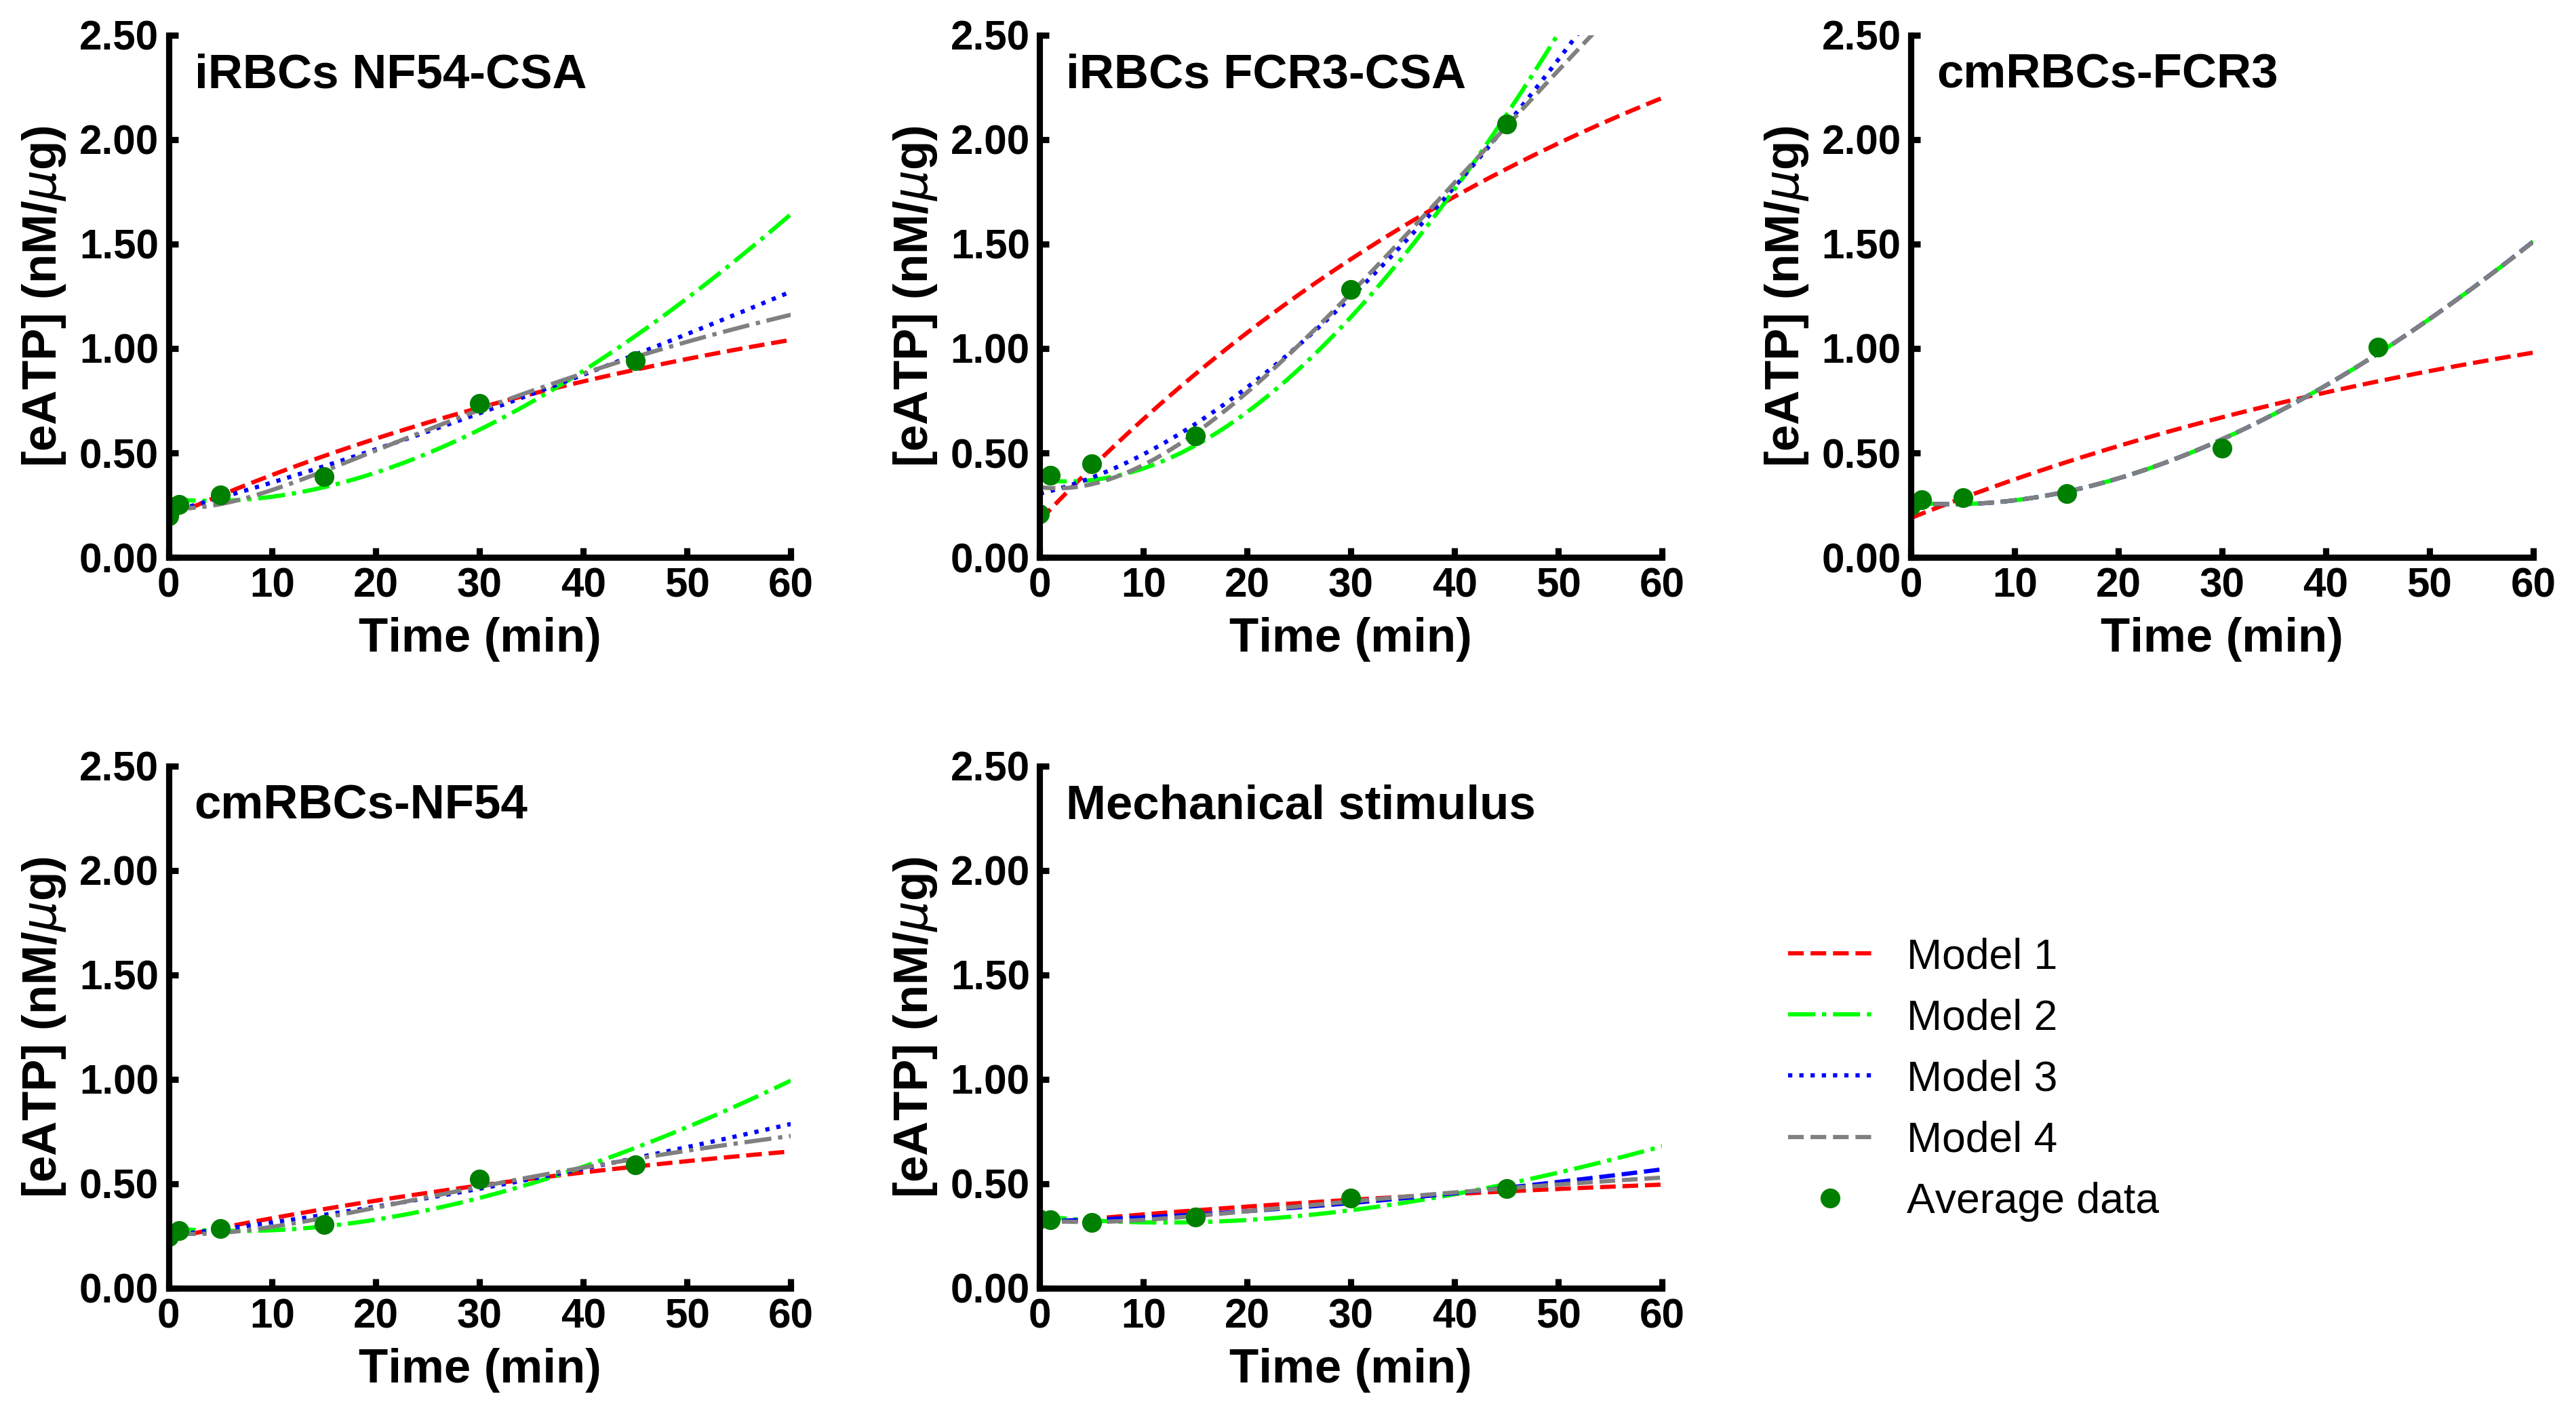

In [16]:
# @title
para_grafico["Eje_y"]='[eATP] (nM/'+r'$ \mu$'+'g)'
fig, cuadros=pl.subplots(2,3,figsize=(15,8),dpi=300,width_ratios=(2,2,2))
cuadro=[]
cuadro.append(cuadros[0][0])
cuadro.append(cuadros[0][1])
cuadro.append(cuadros[1][0])
cuadro.append(cuadros[1][1])
cuadro.append(cuadros[0][2])
cuadro.append(cuadros[1][2])
cuadro[5].set_axis_off()


def simulate_eATP_dynamics_3(t_eval, k_s_b, k_s_m, ATP_0, k_h, dt):
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)
    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0
    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida = k_s_b + k_s_m * t
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt
    return ATP_sim

def simulate_eATP_dynamics_2(t_eval, k_s_m, ATP_0, k_h, dt):
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)
    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0
    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida = k_s_m * t
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt
    return ATP_sim

def simulate_eATP_dynamics_1(t_eval, k_s_b, ATP_0, k_h, dt):
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)
    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0
    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida = k_s_b
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt
    return ATP_sim

def simulate_eATP_dynamics_4(t_eval, k_s_A, k_s_exp, ATP_0, k_h, dt):
    t_max = np.max(t_eval)
    tiempos = np.arange(0, t_max + dt, dt)
    ATP_sim = np.zeros_like(tiempos)
    ATP_sim[0] = ATP_0
    # Euler integration step
    for i in range(1, len(tiempos)):
        t = tiempos[i-1]
        k_salida = k_s_A * (1-np.exp(-k_s_exp*t))
        dATPe_dt = k_salida - ATP_sim[i-1] * k_h
        ATP_sim[i] = ATP_sim[i-1] + dATPe_dt * dt
    return ATP_sim

d={}
dc={}
textox=2.5
textoy=2.25
color_puntos=(0.92,0.92,0.92)

modelo1=pd.read_csv(base+'/Results/Ajustes_Modelo_1_offline.csv')
modelo2=pd.read_csv(base+'/Results/Ajustes_Modelo_2_offline.csv')
modelo3=pd.read_csv(base+'/Results/Ajustes_Modelo_3_offline.csv')
modelo4=pd.read_csv(base+'/Results/Ajustes_Modelo_4_offline.csv')

print(modelo4)

ajustado_x_nf54=np.linspace(0,60,101)
dt2=60/100
ajustado_y_nf54_1=simulate_eATP_dynamics_1(ajustado_x_nf54,modelo1['iRBCs NF54-CSA'].loc[0],modelo1['iRBCs NF54-CSA'].loc[1],k_h_irbc+k_h_c,dt2)
ajustado_y_nf54_2=simulate_eATP_dynamics_2(ajustado_x_nf54,modelo2['iRBCs NF54-CSA'].loc[0],modelo2['iRBCs NF54-CSA'].loc[1],k_h_irbc+k_h_c,dt2)
ajustado_y_nf54_3=simulate_eATP_dynamics_3(ajustado_x_nf54,modelo3['iRBCs NF54-CSA'].loc[0],modelo3['iRBCs NF54-CSA'].loc[1],modelo3['iRBCs NF54-CSA'].loc[2],k_h_irbc+k_h_c,dt2)
ajustado_y_nf54_4=simulate_eATP_dynamics_4(ajustado_x_nf54,modelo4['iRBCs NF54-CSA'].loc[0],modelo4['iRBCs NF54-CSA'].loc[1],modelo4['iRBCs NF54-CSA'].loc[2],k_h_irbc+k_h_c,dt2)


cuadro[0].plot(ajustado_x_nf54,ajustado_y_nf54_1,label='Model 1',color=[1,0,0],ls='--')
cuadro[0].plot(ajustado_x_nf54,ajustado_y_nf54_2,label='Model 2',color=[0,1,0],ls='-.')
cuadro[0].plot(ajustado_x_nf54,ajustado_y_nf54_3,label='Model 3',color=[0,0,1],ls=':')
cuadro[0].plot(ajustado_x_nf54,ajustado_y_nf54_4,label='Model 4',color=[0.5,0.5,0.5],ls='-.')
cuadro[0].text(textox,textoy,'iRBCs NF54-CSA',fuente_titulos)
cuadro[0].plot(data_m_nf54.index,data_m_nf54.values,label='Average Data',marker='o',color='green',ls='')


d['Tiempo']=ajustado_x_nf54
dc['NF-54 data mean time']=data_m_nf54.index
dc['NF-54 data mean']=data_m_nf54.values
d['NF-54 Modelo 1']=ajustado_y_nf54_1
d['NF-54 Modelo 2']=ajustado_y_nf54_2
d['NF-54 Modelo 3']=ajustado_y_nf54_3
d['NF-54 Modelo 4']=ajustado_y_nf54_4

ajustado_y_fcr3_1=simulate_eATP_dynamics_1(ajustado_x_nf54,modelo1['iRBCs FCR3-CSA'].loc[0],modelo1['iRBCs FCR3-CSA'].loc[1],k_h_irbc+k_h_c,dt2)
ajustado_y_fcr3_2=simulate_eATP_dynamics_2(ajustado_x_nf54,modelo2['iRBCs FCR3-CSA'].loc[0],modelo2['iRBCs FCR3-CSA'].loc[1],k_h_irbc+k_h_c,dt2)
ajustado_y_fcr3_3=simulate_eATP_dynamics_3(ajustado_x_nf54,modelo3['iRBCs FCR3-CSA'].loc[0],modelo3['iRBCs FCR3-CSA'].loc[1],modelo3['iRBCs FCR3-CSA'].loc[2],k_h_irbc+k_h_c,dt2)
ajustado_y_fcr3_4=simulate_eATP_dynamics_4(ajustado_x_nf54,modelo4['iRBCs FCR3-CSA'].loc[0],modelo4['iRBCs FCR3-CSA'].loc[1],modelo4['iRBCs FCR3-CSA'].loc[2],k_h_irbc+k_h_c,dt2)


cuadro[1].plot(ajustado_x_nf54,ajustado_y_fcr3_1,label='Model 1',color=[1,0,0],ls='--')
cuadro[1].plot(ajustado_x_nf54,ajustado_y_fcr3_2,label='Model 2',color=[0,1,0],ls='-.')
cuadro[1].plot(ajustado_x_nf54,ajustado_y_fcr3_3,label='Model 3',color=[0,0,1],ls=':')
cuadro[1].plot(ajustado_x_nf54,ajustado_y_fcr3_4,label='Model 4',color=[0.5,0.5,.5],ls='--')

cuadro[1].text(textox,textoy,'iRBCs FCR3-CSA',fuente_titulos)
cuadro[1].plot(data_m_fcr3.index,data_m_fcr3.values,label='Average data',marker='o',color='green',ls='')
cuadro[1].legend(frameon=False,bbox_to_anchor=(1.5, -1),fontsize=15,loc='center')

dc['FCR3 data mean time']=data_m_fcr3.index
dc['FCR3 data mean']=data_m_fcr3.values
d['FCR3 Modelo 1']=ajustado_y_fcr3_1
d['FCR3 Modelo 2']=ajustado_y_fcr3_2
d['FCR3 Modelo 3']=ajustado_y_fcr3_3
d['FCR3 Modelo 4']=ajustado_y_fcr3_4

ajustado_y_rbcs_1=simulate_eATP_dynamics_1(ajustado_x_nf54,modelo1['cmRBCs-FCR3'].loc[0],modelo1['cmRBCs-FCR3'].loc[1],k_h_crbc+k_h_c,dt2)
ajustado_y_rbcs_2=simulate_eATP_dynamics_2(ajustado_x_nf54,modelo2['cmRBCs-FCR3'].loc[0],modelo2['cmRBCs-FCR3'].loc[1],k_h_crbc+k_h_c,dt2)
ajustado_y_rbcs_3=simulate_eATP_dynamics_3(ajustado_x_nf54,modelo3['cmRBCs-FCR3'].loc[0],modelo3['cmRBCs-FCR3'].loc[1],modelo3['cmRBCs-FCR3'].loc[2],k_h_crbc+k_h_c,dt2)
ajustado_y_rbcs_4=simulate_eATP_dynamics_4(ajustado_x_nf54,modelo4['cmRBCs-FCR3'].loc[0],modelo4['cmRBCs-FCR3'].loc[1],modelo4['cmRBCs-FCR3'].loc[2],k_h_crbc+k_h_c,dt2)

cuadro[4].plot(ajustado_x_nf54,ajustado_y_rbcs_1,label='Model 1',color=[1,0,0],ls='--')
cuadro[4].plot(ajustado_x_nf54,ajustado_y_rbcs_2,label='Model 2',color=[0,1,0],ls='-.')
cuadro[4].plot(ajustado_x_nf54,ajustado_y_rbcs_3,label='Model 3',color=[0,0,1],ls='--')
cuadro[4].plot(ajustado_x_nf54,ajustado_y_rbcs_4,label='Model 4',color=[0.5,0.5,0.5],ls='--')

cuadro[4].text(textox,textoy,'cmRBCs-FCR3',fuente_titulos)
cuadro[4].plot(data_m_rbcs.index,data_m_rbcs.values,label='Average data',marker='o',color='green',ls='')

dc['RBCS data mean time']=data_m_rbcs.index
dc['RBCS data mean']=data_m_rbcs.values
d['RBCS Modelo 1']=ajustado_y_rbcs_1
d['RBCS Modelo 2']=ajustado_y_rbcs_2
d['RBCS Modelo 3']=ajustado_y_rbcs_3
d['RBCS Modelo 4']=ajustado_y_rbcs_4


ajustado_y_biwo_1=simulate_eATP_dynamics_1(ajustado_x_nf54,modelo1['Mechanical stimulus'].loc[0],modelo1['Mechanical stimulus'].loc[1],k_h_crbc+k_h_c,dt2)
ajustado_y_biwo_2=simulate_eATP_dynamics_2(ajustado_x_nf54,modelo2['Mechanical stimulus'].loc[0],modelo2['Mechanical stimulus'].loc[1],k_h_crbc+k_h_c,dt2)
ajustado_y_biwo_3=simulate_eATP_dynamics_3(ajustado_x_nf54,modelo3['Mechanical stimulus'].loc[0],modelo3['Mechanical stimulus'].loc[1],modelo3['Mechanical stimulus'].loc[2],k_h_crbc+k_h_c,dt2)
ajustado_y_biwo_4=simulate_eATP_dynamics_4(ajustado_x_nf54,modelo4['Mechanical stimulus'].loc[0],modelo4['Mechanical stimulus'].loc[1],modelo4['Mechanical stimulus'].loc[2],k_h_crbc+k_h_c,dt2)

cuadro[3].plot(ajustado_x_nf54,ajustado_y_biwo_1,label='Model 1',color=[1,0,0],ls='--')
cuadro[3].plot(ajustado_x_nf54,ajustado_y_biwo_2,label='Model 2',color=[0,1,0],ls='-.')
cuadro[3].plot(ajustado_x_nf54,ajustado_y_biwo_3,label='Model 3',color=[0,0,1],ls='--')
cuadro[3].plot(ajustado_x_nf54,ajustado_y_biwo_4,label='Model 4',color=[0.5,0.5,0.5],ls='--')

cuadro[3].text(textox,textoy,'Mechanical stimulus',fuente_titulos)
cuadro[3].plot(data_m_biwo.index,data_m_biwo.values,label='Average data',marker='o',color='green',ls='')

#tablas[3].table(cellText=ajustes4.values,rowLabels=ajustes4.index,loc='center',**fuente_tabla)
dc['Biwo data mean time']=data_m_biwo.index
dc['Biwo data mean']=data_m_biwo.values
d['Biwo Modelo 1']=ajustado_y_biwo_1
d['Biwo Modelo 2']=ajustado_y_biwo_2
d['Biwo Modelo 3']=ajustado_y_biwo_3
#d['Biwo Modelo 4']=ajustado_y_biwo_4
#d['Biwo Modelo 5']=ajustado_y_biwo_5


ajustado_x_cm2r=np.linspace(0,60,101)
dt2=60/100
ajustado_y_cm2r_1=simulate_eATP_dynamics_1(ajustado_x_cm2r,modelo1['cmRBCs-NF54'].loc[0],modelo1['cmRBCs-NF54'].loc[1],k_h_crbc+k_h_c,dt2)
ajustado_y_cm2r_2=simulate_eATP_dynamics_2(ajustado_x_cm2r,modelo2['cmRBCs-NF54'].loc[0],modelo2['cmRBCs-NF54'].loc[1],k_h_crbc+k_h_c,dt2)
ajustado_y_cm2r_3=simulate_eATP_dynamics_3(ajustado_x_cm2r,modelo3['cmRBCs-NF54'].loc[0],modelo3['cmRBCs-NF54'].loc[1],modelo3['cmRBCs-NF54'].loc[2],k_h_crbc+k_h_c,dt2)
ajustado_y_cm2r_4=simulate_eATP_dynamics_4(ajustado_x_cm2r,modelo4['cmRBCs-NF54'].loc[0],modelo4['cmRBCs-NF54'].loc[1],modelo4['cmRBCs-NF54'].loc[2],k_h_crbc+k_h_c,dt2)


cuadro[2].plot(ajustado_x_cm2r,ajustado_y_cm2r_1,label='Model 1',color=[1,0,0],ls='--')
cuadro[2].plot(ajustado_x_cm2r,ajustado_y_cm2r_2,label='Model 2',color=[0,1,0],ls='-.')
cuadro[2].plot(ajustado_x_cm2r,ajustado_y_cm2r_3,label='Model 3',color=[0,0,1],ls=':')
cuadro[2].plot(ajustado_x_cm2r,ajustado_y_cm2r_4,label='Model 4',color=[0.5,0.5,0.5],ls='-.')
cuadro[2].text(textox,textoy,'cmRBCs-NF54',fuente_titulos)
cuadro[2].plot(data_m_cm2r.index,data_m_cm2r.values,label='Average Data',marker='o',color='green',ls='')

dc['cmRBCs-NF54 data mean time']=data_m_cm2r.index
dc['cmRBCs-NF54 data mean']=data_m_cm2r.values
d['cmRBCs-NF54 Modelo 1']=ajustado_y_cm2r_1
d['cmRBCs-NF54 Modelo 2']=ajustado_y_cm2r_2
d['cmRBCs-NF54 Modelo 3']=ajustado_y_cm2r_3

pl.subplots_adjust(wspace=0.4,hspace=0.4)
for i in range(0,5):
  cuadro[i].set_ylim([0,2.5])
  cuadro[i].set_xlim([0,60])
  mejoro_grafico(fig,cuadro[i],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)

d=pd.DataFrame(d)
dc=pd.DataFrame(dc)
d.to_csv('/content/drive/MyDrive/Modelo/Procesed/Off_line/Ajustes.csv')
dc.to_csv('/content/drive/MyDrive/Modelo/Procesed/Off_line/Datos.csv')
fig.savefig('/content/drive/MyDrive/Modelo/Procesed/Off_line/Ajustes.png')

Todos los vectores fueron cargados exitosamente.
Parámetros y errores extraídos correctamente:
NF54 -> par_nf54: [0.00115 0.28   ], err_nf54: [0.00015 0.05   ]
FCR3 -> par_fcr3: [0.00242 0.37   ], err_fcr3: [0.0003 0.13  ]
cmRBCs-FCR3 -> par_rbcs: [0.00103 0.26   ], err_rbcs: [0.00017 0.08   ]
BiWo -> par_biwo: [0.00039 0.34   ], err_biwo: [6.e-05 2.e-02]
cmRBCs-NF54 -> par_cm2r: [0.00064 0.29   ], err_cm2r: [8.e-05 3.e-02]
Jefflux 45 min NF54:  0.051889259478852
Jefflux 45 min FCR3:  0.1089653610937455
Jefflux 45 min RBCs:  0.0463685370540615
Jefflux 45 min Bewo:  0.017730440959824
Jefflux 45 min cmRBCs:  0.0288987971185665


/tmp/ipykernel_6047/256380230.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  cuadro_s[1].legend(frameon=False,loc='upper left')
/tmp/ipykernel_6047/2438107357.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2438107357.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_xticklabels(xs,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2438107357.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_yticklabels(ys,fontsize=parametros["fuente"],**fuente_eje)
/tmp/ipykernel_6047/2

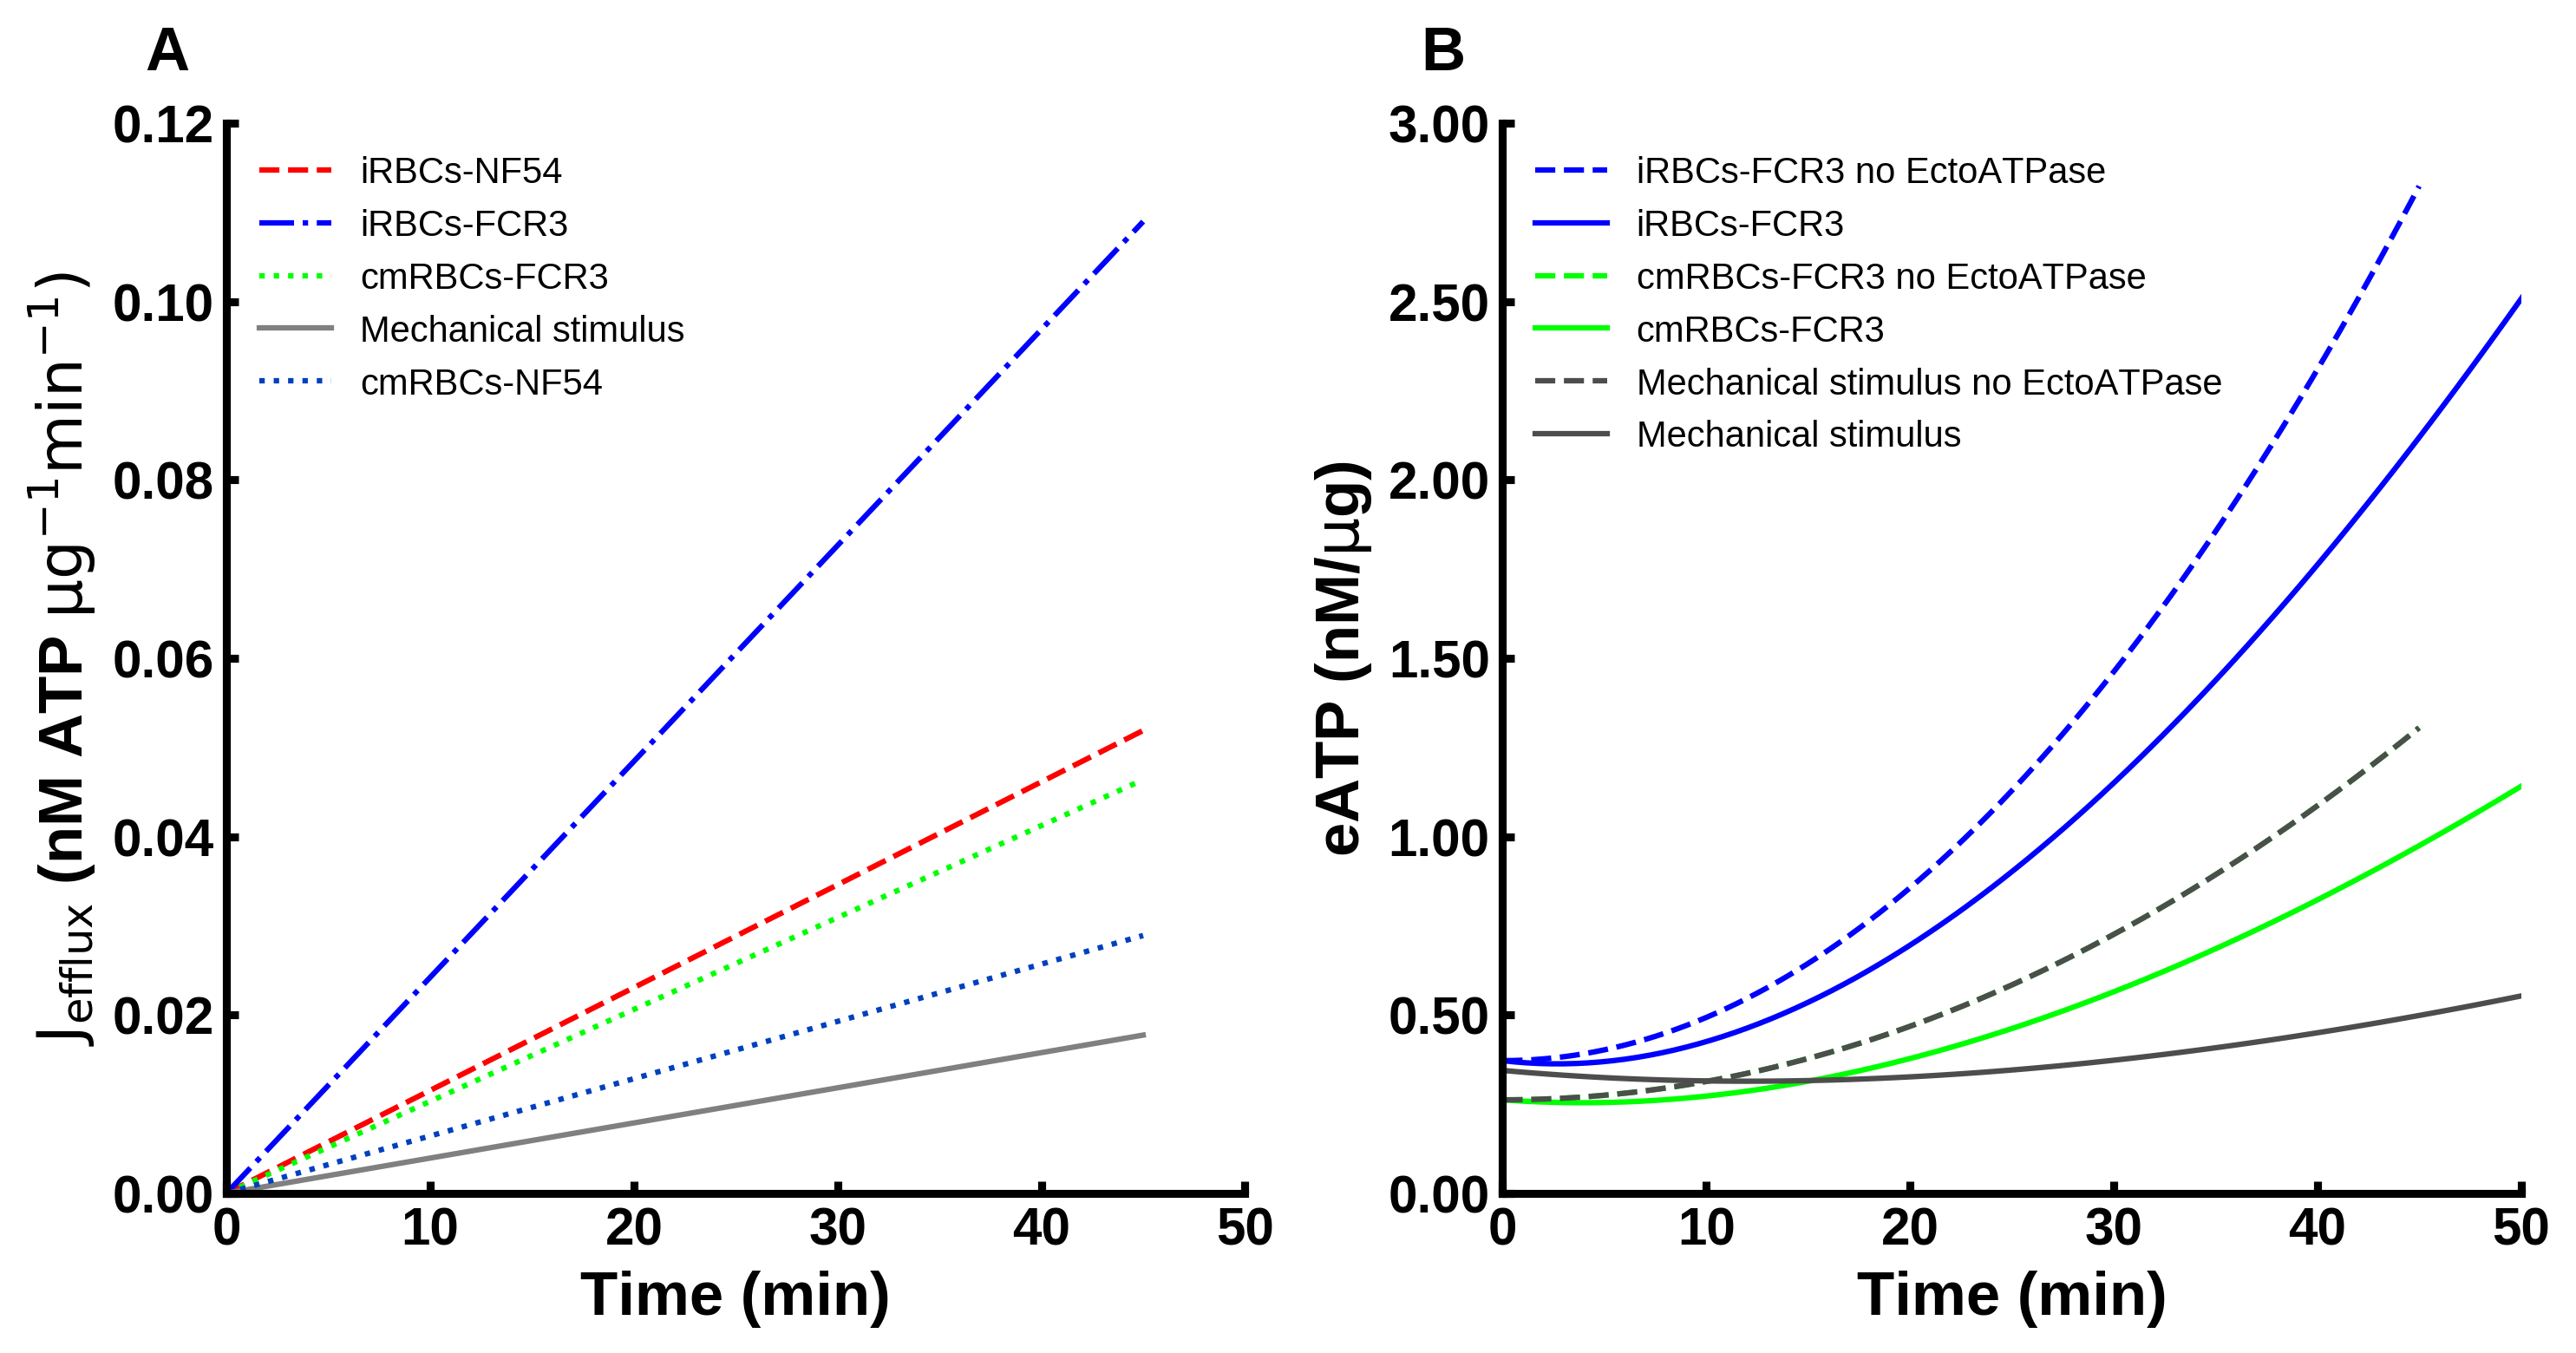

In [17]:
import pandas as pd

sim_dir = base+'/Simulations/'

# 1. Condición NF54
df_nf54 = pd.read_csv(f'{sim_dir}/simulation_NF54.csv')
flux_x_nf54 = df_nf54['time_flux_min'].values
flux_y_nf54 = df_nf54['Jefflux_nM_per_min'].values
out_x_nf54  = df_nf54['time_eATP_min'].values
out_y_nf54  = df_nf54['eATP_no_hydrolysis_nM'].values

# 2. Condición FCR3
df_fcr3 = pd.read_csv(f'{sim_dir}/simulation_FCR3.csv')
flux_x_fcr3 = df_fcr3['time_flux_min'].values
flux_y_fcr3 = df_fcr3['Jefflux_nM_per_min'].values
out_x_fcr3  = df_fcr3['time_eATP_min'].values
out_y_fcr3  = df_fcr3['eATP_no_hydrolysis_nM'].values

# 3. Condición cmRBCs-FCR3
df_rbcs = pd.read_csv(f'{sim_dir}/simulation_cmRBCs_FCR3.csv')
flux_x_rbcs = df_rbcs['time_flux_min'].values
flux_y_rbcs = df_rbcs['Jefflux_nM_per_min'].values
out_x_rbcs  = df_rbcs['time_eATP_min'].values
out_y_rbcs  = df_rbcs['eATP_no_hydrolysis_nM'].values

# 4. Condición BiWo (Estímulo Mecánico)
df_biwo = pd.read_csv(f'{sim_dir}/simulation_BiWo_mechanical.csv')
flux_x_biwo = df_biwo['time_flux_min'].values
flux_y_biwo = df_biwo['Jefflux_nM_per_min'].values
out_x_biwo  = df_biwo['time_eATP_min'].values
out_y_biwo  = df_biwo['eATP_no_hydrolysis_nM'].values

# 5. Explantes (Con hidrólisis)
df_expl_h = pd.read_csv(f'{sim_dir}/simulation_explants_with_hydrolysis.csv')
flux_x_expl = df_expl_h['time_min'].values
flux_y_expl = df_expl_h['eATP_explants_nM'].values

# 6. Explantes (Sin hidrólisis)
df_expl_noh = pd.read_csv(f'{sim_dir}/simulation_explants_no_hydrolysis.csv')
out_x_expl  = df_expl_noh['time_min'].values
out_y_expl  = df_expl_noh['eATP_explants_no_hydrolysis_nM'].values

# 7. Condición cmRBCs-NF54
df_cm2r = pd.read_csv(f'{sim_dir}/simulation_cmRBCS_NF54.csv')
flux_x_cm2r = df_cm2r['time_flux_min'].values
flux_y_cm2r = df_cm2r['Jefflux_nM_per_min'].values
out_x_cm2r  = df_cm2r['time_eATP_min'].values
out_y_cm2r  = df_cm2r['eATP_no_hydrolysis_nM'].values

print("Todos los vectores fueron cargados exitosamente.")


import pandas as pd
import numpy as np

# Cargar el archivo suplementario generado previamente
supp_path = base+'/Results/Supplementary_modelo2.csv'
df_supp = pd.read_csv(supp_path, sep=';', decimal=',')


def parse_val_and_err(text):
    """Parsea cadenas con formato 'val ± err' o '(val ± err)x10-3' a floats."""
    scale = 1.0
    text_clean = text.strip()

    # Manejar notación científica si está expresada como x10-3
    if 'x10-3' in text_clean:
        scale = 1e-3
        text_clean = text_clean.replace('x10-3', '').replace('(', '').replace(')', '')

    val_str, err_str = text_clean.split('±')
    val = float(val_str.strip().replace(',', '.')) * scale
    err = float(err_str.strip().replace(',', '.')) * scale
    return val, err

def extract_condition_params(column_name):
    """Extrae vectores de parámetros [k_s_m, ATP_0] y sus errores [err_k_s_m, err_ATP_0]."""
    # Fila 0: Parameter kefflux-variable
    ksm, err_ksm = parse_val_and_err(df_supp[column_name].iloc[0])
    # Fila 1: Initial [eATP]
    atp0, err_atp0 = parse_val_and_err(df_supp[column_name].iloc[1])

    par = np.array([ksm, atp0])
    err = np.array([err_ksm, err_atp0])
    return par, err

# Mapeo de columnas del archivo CSV a variables
par_nf54, err_nf54 = extract_condition_params('iRBCs NF54-CSA')
par_fcr3, err_fcr3 = extract_condition_params('iRBCs FCR3-CSA')
par_rbcs, err_rbcs = extract_condition_params('cmRBCs-FCR3')
par_biwo, err_biwo = extract_condition_params('Mechanical stimulus')
par_cm2r, err_cm2r = extract_condition_params('cmRBCs-NF54')

print("Parámetros y errores extraídos correctamente:")
print(f"NF54 -> par_nf54: {par_nf54}, err_nf54: {err_nf54}")
print(f"FCR3 -> par_fcr3: {par_fcr3}, err_fcr3: {err_fcr3}")
print(f"cmRBCs-FCR3 -> par_rbcs: {par_rbcs}, err_rbcs: {err_rbcs}")
print(f"BiWo -> par_biwo: {par_biwo}, err_biwo: {err_biwo}")
print(f"cmRBCs-NF54 -> par_cm2r: {par_cm2r}, err_cm2r: {err_cm2r}")

fig2, cuadro_s=pl.subplots(1,2,figsize=(10,5),dpi=300)
cuadro_s=cuadro_s.flatten()

import matplotlib.gridspec as gridspec

fig = pl.figure(figsize=(10, 15), dpi=300)
# Definimos una grilla base de 2 filas x 6 columnas
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.5)
# Fila 1: 2 paneles (cada uno ocupa 3 columnas)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[1, 0])
# Fila 2: 3 paneles (cada uno ocupa 2 columnas)
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])
# Guardamos todos los paneles en tu lista ordenada cuadro_p
cuadro_p = [ax1, ax2, ax3, ax4, ax5]


import matplotlib as mpl
mpl.rcParams["mathtext.fontset"] ='stixsans'


import matplotlib.image as mpimg

img = mpimg.imread('/content/drive/MyDrive/Modelo/data/Esquema.jpg')
cuadro_p[0].set_axis_off()
cuadro_p[0].imshow(img)


cuadro_s[0].plot(flux_x_nf54,flux_y_nf54,label='iRBCs-NF54',color=[1,0,0],ls='--')
cuadro_s[0].plot(flux_x_fcr3,flux_y_fcr3,label='iRBCs-FCR3',color=[0,0,1],ls='-.')
cuadro_s[0].plot(flux_x_rbcs,flux_y_rbcs,label='cmRBCs-FCR3',color=[0,1,0],ls=':')
cuadro_s[0].plot(flux_x_biwo,flux_y_biwo,label='Mechanical stimulus',color=[0.5,0.5,0.5])
cuadro_s[0].plot(flux_x_cm2r,flux_y_cm2r,label='cmRBCs-NF54',color=[0,0.25,0.75],ls=':')
cuadro_s[0].legend(frameon=False,loc='upper left')
cuadro_s[0].set_xlim([0,50])
cuadro_s[0].set_ylim([0,0.12])
n=len(flux_x_nf54)-1
print('Jefflux 45 min NF54: ',flux_y_nf54[n])
print('Jefflux 45 min FCR3: ',flux_y_fcr3[n])
print('Jefflux 45 min RBCs: ',flux_y_rbcs[n])
print('Jefflux 45 min Bewo: ',flux_y_biwo[n])
print('Jefflux 45 min cmRBCs: ',flux_y_cm2r[n])
cuadro_s[1].legend(frameon=False,loc='upper left')

cuadro_p[2].bar([1],flux_y_nf54[n],color=[1,0,0],label='iRBCs-NF54')
cuadro_p[2].errorbar([1],flux_y_nf54[n],flux_y_nf54[n]*err_nf54[0]/par_nf54[0],color=[1,0,0],fmt='none',ecolor=[1,0,0],capsize=para_grafico['Error_ancho'],elinewidth=para_grafico['Grosor'])
cuadro_p[2].bar([2],flux_y_fcr3[n],color=[0,0,1],label='iRBCs-FCR3')
cuadro_p[2].errorbar([2],flux_y_fcr3[n],flux_y_fcr3[n]*err_fcr3[0]/par_fcr3[0],color=[0,0,1],fmt='none',ecolor=[0,0,1],capsize=para_grafico['Error_ancho'],elinewidth=para_grafico['Grosor'])
cuadro_p[2].bar([3],flux_y_rbcs[n],color=[0,1,0],label='cmRBCs-FCR3')
cuadro_p[2].errorbar([3],flux_y_rbcs[n],flux_y_rbcs[n]*err_rbcs[0]/par_rbcs[0],color=[0,1,0],fmt='none',ecolor=[0,1,0],capsize=para_grafico['Error_ancho'],elinewidth=para_grafico['Grosor'])
cuadro_p[2].bar([4],flux_y_biwo[n],color=[0.5,0.5,0.5],label='Mechanical stimulus')
cuadro_p[2].errorbar([4],flux_y_biwo[n],flux_y_biwo[n]*err_biwo[0]/par_biwo[0],color=[0.5,0.5,0.5],fmt='none',ecolor=[0.5,0.5,0.5],capsize=para_grafico['Error_ancho'],elinewidth=para_grafico['Grosor'])
cuadro_p[2].bar([5],flux_y_cm2r[n],color=[0,0.25,0.75],label='cmRBCs-NF54')
cuadro_p[2].errorbar([5],flux_y_cm2r[n],flux_y_cm2r[n]*err_cm2r[0]/par_cm2r[0],color=[0,0.25,0.75],fmt='none',ecolor=[0,0.25,0.75],capsize=para_grafico['Error_ancho'],elinewidth=para_grafico['Grosor'])

para_grafico['Simbolo']=4
cuadro_p[1].plot(data_m_nf54.index,data_m_nf54.values,label='iRBCs-NF54',color=[1,0,0],marker='o',ms=para_grafico['Simbolo'],ls='')
cuadro_p[1].plot(ajustado_x_nf54,ajustado_y_nf54_2,color=[1,0,0],ls='-')
cuadro_p[1].plot(data_m_fcr3.index,data_m_fcr3.values,label='iRBCs-FCR3',color=[0,0,1],marker='s',ms=para_grafico['Simbolo'],ls='')
cuadro_p[1].plot(ajustado_x_nf54,ajustado_y_fcr3_2,color=[0,0,1],ls='-')
cuadro_p[1].plot(data_m_rbcs.index,data_m_rbcs.values,label='cmRBCs-FCR3',color=[0,1,0],marker='^',ms=para_grafico['Simbolo'],ls='')
cuadro_p[1].plot(ajustado_x_nf54,ajustado_y_rbcs_2,color=[0,1,0],ls='-')
cuadro_p[1].plot(data_m_biwo.index,data_m_biwo.values,label='Mechanical stimulus',color=[0.3,0.3,0.3],marker='v',ms=para_grafico['Simbolo'],ls='')
cuadro_p[1].plot(ajustado_x_nf54,ajustado_y_biwo_2,color=[0.3,0.3,0.3],ls='-')
cuadro_p[1].plot(data_m_cm2r.index,data_m_cm2r.values,label='cmRBCs-NF54',color=[0,0.25,0.75],marker='*',ms=para_grafico['Simbolo'],ls='')
cuadro_p[1].plot(ajustado_x_nf54,ajustado_y_cm2r_2,color=[0,0.25,0.75],ls='-')

cuadro_p[1].legend(frameon=False,loc='upper left')
cuadro_p[1].set_xlim([0,50])
cuadro_p[1].set_ylim([0,2.5])
para_grafico["Eje_y"]='eATP (nM/'+r'$ \mathrm{ \mu}$'+'g)'
mejoro_grafico(fig,cuadro_p[1],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)
para_grafico["Eje_y"]=r'$\mathrm{ J_{efflux}}$'+' (nM ATP '+r'$\mathrm{ \mu }$'+r'$\mathrm{ g^{-1} min^{-1})}$'

mejoro_grafico3(fig,cuadro_p[2],para_grafico,fuente_titulos,fuente_ejes,fuente_legend,fuente_pequeña,['iRBCs\nNF54','iRBCs\nFCR3','cmRBCs\n-FCR3','Mechanical\nstimulus.','cmRBCs\n-NF54'])
mejoro_grafico2(fig2,cuadro_s[1],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)
mejoro_grafico2(fig2,cuadro_s[0],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)

#cuadro[3].plot(out_x_nf54,out_y_nf54,label='iRBCs-NF54',color=[1,0,0],marker='',ms=para_grafico['Simbolo'],ls='dashed')
#cuadro[3].plot(ajustado_x_nf54_2,ajustado_y_nf54_2,color=[1,0,0],ls='-')
cuadro_s[1].plot(out_x_fcr3,out_y_fcr3,label='iRBCs-FCR3 no EctoATPase',color=[0,0,1],marker='',ms=para_grafico['Simbolo'],ls='dashed')
cuadro_s[1].plot(ajustado_x_nf54,ajustado_y_fcr3_2,label='iRBCs-FCR3',color=[0,0,1],ls='-')
cuadro_s[1].plot(out_x_rbcs,out_y_rbcs,label='cmRBCs-FCR3 no EctoATPase',color=[0,1,0],marker='',ms=para_grafico['Simbolo'],ls='dashed')
cuadro_s[1].plot(ajustado_x_nf54,ajustado_y_rbcs_2,label='cmRBCs-FCR3',color=[0,1,0],ls='-')
cuadro_s[1].plot(out_x_biwo,out_y_biwo,label='Mechanical stimulus no EctoATPase',color=[0.3,0.3,0.3],marker='',ms=para_grafico['Simbolo'],ls='dashed')
cuadro_s[1].plot(ajustado_x_nf54,ajustado_y_biwo_2,label='Mechanical stimulus',color=[0.3,0.3,0.3],ls='-')
cuadro_s[1].legend(frameon=False,loc='upper left')
cuadro_s[1].set_xlim([0,50])
cuadro_s[1].set_ylim([0,3.0])
para_grafico["Eje_y"]='eATP (nM/'+r'$ \mathrm{ \mu}$'+'g)'
mejoro_grafico(fig,cuadro_s[1],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)

cuadro_p[3].plot(out_x_fcr3,np.array(out_y_fcr3),label=r'predicted [eATP] if null EctoATPase',color=[0,0.5,1],marker='',ms=para_grafico['Simbolo'],ls='dashed')
cuadro_p[3].plot(ajustado_x_nf54,np.array(ajustado_y_fcr3_2),color=[0,0,1],ls='-',label='[eATP]')
cuadro_p[3].text(40,630,'FCR3',**fuente_titulos)

#tiempo_simul=np.arange(0, 45, 0.2)
#ajustado_y_fcr3_final_2=simulate_eATP_dynamics_2(tiempo_simul,modelo2['iRBCs FCR3-CSA'].loc[0],modelo2['iRBCs FCR3-CSA'].loc[1],k_h_irbc+k_h_c,0.2)
remanente=np.array(out_y_fcr3)-np.array(y_expl)
cuadro_p[3].plot(out_x_fcr3,remanente,label='derived [eADP]+[eAMP]+[eADO]',color=[0.5,0,1],marker='',ms=para_grafico['Simbolo'],ls='-.')

cuadro_p[3].legend(frameon=False,loc='upper left')
cuadro_p[3].set_xlim([0,50])
cuadro_p[3].set_ylim([0,3])
para_grafico["Eje_y"]='[Nucleotide] (nM/'+r'$ \mathrm{ \mu}$'+'g)'
fuente_ejes2 = {'family':'Arimo','size':str(para_grafico["fuente"]*15/20),'weight':'bold'}
cuadro_p[3].text(2,1.8,"Cytotrophoblast",**fuente_ejes2)
mejoro_grafico(fig,cuadro_p[3],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)

cuadro_p[4].plot(flux_x_expl,flux_y_expl,label=r'predicted [eATP]',color=[0,0,1],marker='',ls='-')
remanente=np.array(out_y_expl)-np.array(flux_y_expl)
cuadro_p[4].plot(out_x_expl,remanente,label='derived [eADP]+[eAMP]+[eADO]',color=[0.5,0,1],marker='',ms=para_grafico['Simbolo'],ls='-.')
para_grafico["Eje_y"]='[Nucleotide] (nM/'+r'$ \mathrm{ \mu}$'+'g)'
cuadro_p[4].text(2,0.96,"Explants",**fuente_ejes2)
cuadro_p[4].set_xlim([0,50])
cuadro_p[4].set_ylim([0,1.6])
cuadro_p[4].legend(frameon=False,loc='upper left')
mejoro_grafico(fig,cuadro_p[4],para_grafico,fuente_titulos,fuente_ejes,fuente_legend)
fig.tight_layout()
fig2.tight_layout()
agregar_letras_paneles(cuadro_p, x=-0.08, y=1.05, formato="A", estilo=fuente_titulos)
fig.savefig('/content/drive/MyDrive/Modelo/Procesed/Off_line/Fluxb.png')
agregar_letras_paneles(cuadro_s, x=-0.08, y=1.05, formato="A", estilo=fuente_titulos)
fig2.savefig('/content/drive/MyDrive/Modelo/Procesed/Off_line/Supp_2.png')